# КЕЙС 1. Декомпозиция кривой доходности на ожидания и премию за срочность

> **MacroHack | Банк России | 4–14 апреля 2026**

---
| Блок | Задание | Баллы |
|------|---------|-------|
| **БЛОК 1** | Декомпозиция кривой + PCA/ICA + нарративный анализ + международное сравнение | 25 + до 50 доп. |
| **БЛОК 2** | Прогнозная сила ожиданий: КС, ИПЦ, REER, разрыв выпуска | 50 + до 25 доп. |
| **БЛОК 3** | Факторный анализ Term Premium — два набора факторов | 50 + до 50 доп. |
| **БЛОК 4** | Рекомендации по ДКП | бизнес-жюри |

## 0. Установка библиотек

In [1]:
# !pip install -q statsmodels scikit-learn scipy openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA, FastICA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.filters.hp_filter import hpfilter
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats

# Глобальный стиль графиков
plt.rcParams.update({
    'figure.figsize': (14, 5), 'axes.grid': True, 'grid.alpha': 0.3,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'axes.spines.top': False, 'axes.spines.right': False
})
C = plt.cm.tab10.colors

# Аннотации ключевых событий
KEY_EVENTS = [
    ('2015-01', 'Кризис\n2015', 'red'),
    ('2022-02', 'СВО\n2022', 'darkred'),
    ('2023-08', 'Ужесточение\n2023', 'darkorange'),
    ('2024-10', 'Пик\nставки 21%', 'purple'),
]

def add_events(ax, y_pos=None):
    """Добавляет вертикальные линии ключевых событий на график"""
    for dt, lbl, c in KEY_EVENTS:
        ax.axvline(pd.Timestamp(dt), color=c, ls='--', alpha=0.45, lw=1.2)
        if y_pos is not None:
            ax.text(pd.Timestamp(dt), y_pos, lbl, fontsize=7.5, ha='center', color=c)

## 1. Загрузка ВСЕХ файлов данных

**Загрузите все файлы через левую панель Colab (иконка папки → Upload):**

| Файл | Содержимое | Используется в |
|------|------------|----------------|
| `Case_1_yield_curve.xlsx` | Кривая ОФЗ (O/N, 1W…2Y) | Блок 1 — основа |
| `россия_-52002.xlsx` | ОФЗ 2Y YTM (дневные) | Блок 1 — TP |
| `россия_-52003.xlsx` | ОФЗ 3Y YTM (дневные) | Блок 1 — TP |
| `россия_-52004.xlsx` | ОФЗ 5Y YTM (дневные) | Блок 1 — TP |
| `RC_F02_04_2026_T09_04_2026.xlsx` | Сделки с ОФЗ (ruo, vol) | Блок 1 — ликвидность |
| `cbr_keyrate.xlsx` | Ключевая ставка ЦБ РФ | Блок 1,2,3,4 |
| `ust-3m-ytm-combined.xlsx` | UST 3M YTM | Блок 3 — глобальный фактор |
| `ust_10y_ytm_full.xlsx` | UST 10Y YTM | Блок 3 — страновой спред |
| `THREEFYTP10_US_.xlsx` | US Term Premium ACM (ФРС) | Блок 1 — международное сравнение |
| `exchange_rate.xlsx` | REER рубля (ЦБ РФ) | Блок 2 — прогнозирование REER |
| `ipc_mes_03-2026.xlsx` | ИПЦ помесячно (Росстат) | Блок 2 — прогнозирование инфляции |
| `VVP_kvartal_s_1995-2025.xlsx` | ВВП поквартально с/к (Росстат) | Блок 2 — разрыв выпуска |

In [2]:
# 1.1  КРИВАЯ ОФЗ (Case_1_yield_curve.xlsx)

df_yc = pd.read_excel('Case_1_yield_curve.xlsx', sheet_name='Sheet1')
df_yc['Month'] = pd.to_datetime(df_yc['Month'])
df_yc = df_yc.set_index('Month').sort_index().apply(pd.to_numeric, errors='coerce')

tenor_map = {'O/N':1/365,'1W':7/365,'2W':14/365,'1M':1/12,'2M':2/12,
             '3M':3/12,'6M':6/12,'1Y':1,'2Y':2,'3Y':3,'5Y':5,'7Y':7,'10Y':10}
tenors_avail = [c for c in tenor_map if c in df_yc.columns]
tenor_years  = [tenor_map[t] for t in tenors_avail]
df_yc = df_yc[tenors_avail]

print(f'Кривая ОФЗ: {df_yc.index[0].date()} — {df_yc.index[-1].date()}')
print(f'Срочности: {tenors_avail}')

Кривая ОФЗ: 2012-02-29 — 2026-03-31
Срочности: ['O/N', '1W', '2W', '1M', '2M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y']


In [3]:
# 1.2  YTM ОФЗ 2Y / 3Y / 5Y (дневные)

def load_ofz(path, col):
    d = pd.read_excel(path)
    d.columns = ['date', col]
    d['date'] = pd.to_datetime(d['date'])
    d[col] = pd.to_numeric(d[col], errors='coerce')
    return d.set_index('date').sort_index()

ofz2 = load_ofz('россия,-52002.xlsx', 'OFZ_2Y')
ofz3 = load_ofz('россия,-52003.xlsx', 'OFZ_3Y')
ofz5 = load_ofz('россия,-52004.xlsx', 'OFZ_5Y')
ofz_daily = ofz2.join(ofz3, how='outer').join(ofz5, how='outer').sort_index()
ofz_m = ofz_daily.resample('ME').mean()

print(f'ОФЗ дневные: {ofz_daily.index[0].date()} — {ofz_daily.index[-1].date()}')
print(f'Колонки: {list(ofz_daily.columns)}')
ofz_daily.tail(3)

ОФЗ дневные: 2018-04-04 — 2026-04-10
Колонки: ['OFZ_2Y', 'OFZ_3Y', 'OFZ_5Y']


,OFZ_2Y,OFZ_3Y,OFZ_5Y
date,,,
2026-04-08,4.62,6.34,6.55
2026-04-09,4.97,6.48,6.55
2026-04-10,4.88,6.33,6.52


In [4]:
# 1.3  СДЕЛКИ ОФЗ
#      DT=дата, ruo=доходность, vol=объём, T=tenor, C=coupon
rc = pd.read_excel('RC_F02_04_2026_T09_04_2026.xlsx', sheet_name='RC')
rc['DT'] = pd.to_datetime(rc['DT'])
rc = rc.sort_values('DT')

# Средневзвешенная доходность по объёму (для прокси ликвидности)
rc_vol_m = rc.groupby(rc['DT'].dt.to_period('M'))['vol'].sum().rename('trade_vol')
rc_vol_m.index = rc_vol_m.index.to_timestamp(how='end')

print(f'Сделки ОФЗ: {rc["DT"].min().date()} — {rc["DT"].max().date()}, строк: {len(rc)}')
rc.head(3)

Сделки ОФЗ: 2026-04-02 — 2026-04-09, строк: 6


,DT,ruo,vol,T,C,MinRate,Percentile25,Percentile75,MaxRate,StatusXML,DateUpdate
5,2026-04-02,14.91,630.47,56,21,14.65,14.81,14.95,15.25,0,2026-04-03 14:19:05.953
4,2026-04-03,14.92,861.40,72,20,14.70,14.85,14.95,15.25,0,2026-04-06 14:18:59.500
3,2026-04-06,14.88,785.47,69,17,14.48,14.80,14.90,15.00,0,2026-04-07 14:55:30.247


In [5]:
# 1.4  КЛЮЧЕВАЯ СТАВКА ЦБ РФ
cbr_raw = pd.read_excel('cbr_keyrate.xlsx', sheet_name='Дневные')
cbr_raw.columns = ['date', 'key_rate']
cbr_raw['date'] = pd.to_datetime(cbr_raw['date'])
cbr_raw['key_rate'] = pd.to_numeric(cbr_raw['key_rate'], errors='coerce')
cbr_daily = cbr_raw.set_index('date').sort_index().dropna()
cbr_m = cbr_daily['key_rate'].resample('ME').last()

print(f'Ключевая ставка: {cbr_daily.index[0].date()} — {cbr_daily.index[-1].date()}')
print(f'Текущее значение: {cbr_m.iloc[-1]:.1f}%')

Ключевая ставка: 2013-09-17 — 2026-04-13
Текущее значение: 15.0%


In [6]:
# 1.5  UST 3M и 10Y

def load_series(path, col):
    d = pd.read_excel(path)
    d.columns = ['date', col]
    d['date'] = pd.to_datetime(d['date'])
    d[col] = pd.to_numeric(d[col], errors='coerce')
    return d.set_index('date').sort_index()

ust3m  = load_series('ust-3m-ytm-combined.xlsx', 'UST_3M')
ust10y = load_series('ust_10y_ytm_full.xlsx',    'UST_10Y')

ust3m_m  = ust3m.resample('ME').mean()
ust10y_m = ust10y.resample('ME').mean()

print(f'UST 3M:  {ust3m.index[0].date()} — {ust3m.index[-1].date()}')
print(f'UST 10Y: {ust10y.index[0].date()} — {ust10y.index[-1].date()}')

UST 3M:  2012-01-02 — 2026-04-10
UST 10Y: 2012-01-02 — 2026-04-10


In [7]:
# 1.6  US TERM PREMIUM ACM

tp_us_raw = pd.read_excel('THREEFYTP10(US).xlsx', sheet_name='Daily')
tp_us_raw.columns = ['date', 'US_TP_10Y']
tp_us_raw['date'] = pd.to_datetime(tp_us_raw['date'])
tp_us_raw['US_TP_10Y'] = pd.to_numeric(tp_us_raw['US_TP_10Y'], errors='coerce')
tp_us_daily = tp_us_raw.set_index('date').sort_index().dropna()
tp_us_m = tp_us_daily.resample('ME').mean()

print(f'US Term Premium (ACM): {tp_us_daily.index[0].date()} — {tp_us_daily.index[-1].date()}')
print(f'Текущее значение: {tp_us_m["US_TP_10Y"].iloc[-1]:.3f}%')

US Term Premium (ACM): 2012-01-03 — 2026-04-03
Текущее значение: 0.664%


In [8]:
# 1.7  ИПЦ ПОМЕСЯЧНО

cpi_raw = pd.read_excel('ipc_mes_03-2026.xlsx', sheet_name='01', header=None)

years_cpi  = cpi_raw.iloc[3, 1:].values   # строка 3 = годы
month_names = ['январь','февраль','март','апрель','май','июнь',
               'июль','август','сентябрь','октябрь','ноябрь','декабрь']

cpi_long = []
for i in range(5, 17):    # строки 5-16 = январь-декабрь (к пред. месяцу)
    row    = cpi_raw.iloc[i]
    m_name = str(row.iloc[0]).strip().lower()
    if m_name not in month_names:
        continue
    m_num = month_names.index(m_name) + 1
    for j, yr in enumerate(years_cpi):
        try:
            yr_int = int(float(str(yr)))
            val    = float(row.iloc[j + 1])
            if 80 < val < 150:      # фильтр разумных значений
                cpi_long.append({'date': pd.Timestamp(year=yr_int, month=m_num, day=1),
                                 'CPI_mm': val})
        except:
            pass

cpi = pd.DataFrame(cpi_long).set_index('date').sort_index()
cpi = cpi[~cpi.index.duplicated(keep='first')]

# YoY = произведение 12 последних мм-индексов
cpi['CPI_yoy'] = cpi['CPI_mm'].rolling(12).apply(
    lambda x: np.prod(x / 100) * 100 - 100, raw=True)

# МоМ в %
cpi['CPI_mom_pct'] = cpi['CPI_mm'] - 100

cpi_m  = cpi[['CPI_yoy', 'CPI_mom_pct']]

print(f'ИПЦ: {cpi.index[0].date()} — {cpi.index[-1].date()}, строк: {len(cpi)}')
print(f'Последние значения YoY:')
print(cpi['CPI_yoy'].dropna().tail(6).round(2))

ИПЦ: 1991-01-01 — 2026-03-01, строк: 421
Последние значения YoY:
date
2025-10-01    7.73
2025-11-01    6.65
2025-12-01    5.60
2026-01-01    6.01
2026-02-01    5.92
2026-03-01    5.87
Name: CPI_yoy, dtype: float64


In [9]:
# 1.8  REER РУБЛЯ

reer_raw = pd.read_excel('exchange_rate.xlsx', sheet_name='Ежемесячные', header=None)

years_r  = reer_raw.iloc[1, 1:].values
months_r = reer_raw.iloc[2, 1:].values
reer_mom_vals = reer_raw.iloc[30, 1:].values    # строка 30 = REER % к пред. мес.

month_map_r = {'Янв':1,'Фев':2,'Мар':3,'Апр':4,'Май':5,'Июн':6,
               'Июл':7,'Авг':8,'Сен':9,'Окт':10,'Ноя':11,'Дек':12}

reer_dates, reer_vals = [], []
for y, m, v in zip(years_r, months_r, reer_mom_vals):
    try:
        yr = int(float(str(y)))
        mn = month_map_r.get(str(m).strip())
        v2 = float(str(v).replace(',', '.'))
        if mn and yr >= 2010:
            reer_dates.append(pd.Timestamp(year=yr, month=mn, day=1))
            reer_vals.append(v2)
    except:
        pass

reer_mom   = pd.Series(reer_vals, index=reer_dates, name='REER_mom').sort_index()
reer_mom   = reer_mom[~reer_mom.index.duplicated(keep='first')].dropna()

# Кумулятивный индекс уровня (база = 1-е наблюдение = 100)
reer_level = (1 + reer_mom / 100).cumprod() * 100
reer_level.name = 'REER_level'

# YoY накопленный
reer_yoy   = reer_mom.rolling(12).apply(lambda x: np.prod(1 + x/100)*100 - 100, raw=True)
reer_yoy.name = 'REER_yoy'

reer_df = pd.concat([reer_mom, reer_level, reer_yoy], axis=1)

print(f'REER: {reer_mom.index[0].date()} — {reer_mom.index[-1].date()}')
print(f'Последние значения:')
print(reer_df.dropna().tail(6).round(2))

REER: 2010-01-01 — 2026-02-01
Последние значения:
            REER_mom  REER_level  REER_yoy
2025-09-01      -3.6      104.49     15.29
2025-10-01       2.5      107.10     23.35
2025-11-01       1.0      108.17     26.10
2025-12-01       2.1      110.44     27.85
2026-01-01       1.8      112.43     26.61
2026-02-01       0.7      113.22     17.83


In [10]:
# ============================================================
# 1.9 | ВВП С СЕЗОННОЙ КОРРЕКТИРОВКОЙ ДО 2025 ГОДА
# Лист 10: "Валовой внутренний продукт ... (в ценах 2021г., млрд.руб., с исключением сезонного фактора)"
# ============================================================

import pandas as pd
import numpy as np
import re
from statsmodels.tsa.filters.hp_filter import hpfilter

# --- 1. Читаем нужный лист ---
gdp_raw = pd.read_excel(
    'VVP_kvartal_s_1995-2025.xlsx',
    sheet_name='10',
    header=None
)

# --- 2. Карта кварталов ---
qtr_map = {
    'I квартал': 1,
    'II квартал': 4,
    'III квартал': 7,
    'IV квартал': 10,
}

# --- 3. Универсальный парсер года ---
def parse_year_cell(x):
    """
    Извлекает год даже из строк вида '20222)' или '20252)'.
    Берем первые 4 подряд идущие цифры.
    """
    if pd.isna(x):
        return None
    s = str(x).strip()
    m = re.search(r'(\d{4})', s)
    if m:
        return int(m.group(1))
    return None

# --- 4. Собираем квартальный ряд ---
gdp_dates = []
gdp_data = []
current_year = None

# В этом файле:
# строка 2 = годы
# строка 3 = кварталы
# строка 4 = значения
for col in range(gdp_raw.shape[1]):
    y = gdp_raw.iloc[2, col]
    q = gdp_raw.iloc[3, col]
    v = gdp_raw.iloc[4, col]

    # обновляем текущий год, если в ячейке он есть
    parsed_year = parse_year_cell(y)
    if parsed_year is not None:
        current_year = parsed_year

    # квартал
    q_str = str(q).strip()
    month = qtr_map.get(q_str)

    # значение
    val = pd.to_numeric(v, errors='coerce')

    if current_year is not None and month is not None and pd.notna(val) and val > 0:
        gdp_dates.append(pd.Timestamp(year=current_year, month=month, day=1))
        gdp_data.append(float(val))

# --- 5. Формируем Series ---
gdp_q = pd.Series(
    gdp_data,
    index=pd.DatetimeIndex(gdp_dates),
    name='GDP_sa'
).sort_index()

gdp_q = gdp_q[~gdp_q.index.duplicated(keep='first')].dropna()
gdp_q = gdp_q.asfreq('QS')

# --- 6. Строим output gap через HP-фильтр по лог-ВВП ---
log_gdp_q = np.log(gdp_q)
gdp_cycle, gdp_trend = hpfilter(log_gdp_q, lamb=1600)

output_gap = 100 * gdp_cycle
output_gap.name = 'output_gap'

# --- 7. Перевод в месячную частоту ---
monthly_index = pd.date_range(
    start=output_gap.index.min(),
    end=output_gap.index.max(),
    freq='ME'
)

output_gap_m = (
    output_gap.reindex(output_gap.index.union(monthly_index))
    .sort_index()
    .interpolate(method='time')
    .reindex(monthly_index)
)

output_gap_m.name = 'output_gap'

# --- 8. Проверка ---
print('ПРОВЕРКА GDP:')
print('start:', gdp_q.index.min())
print('end  :', gdp_q.index.max())
print('n    :', len(gdp_q))

print('\nПоследние квартальные значения GDP:')
print(gdp_q.tail(8))

print('\nПРОВЕРКА OUTPUT GAP:')
print('start:', output_gap_m.index.min())
print('end  :', output_gap_m.index.max())
print('n    :', len(output_gap_m))
print('non-null:', output_gap_m.notna().sum())
print('nulls   :', output_gap_m.isna().sum())

print('\nПоследние значения output_gap_m:')
print(output_gap_m.tail(6).round(2))

ПРОВЕРКА GDP:
start: 2011-01-01 00:00:00
end  : 2025-10-01 00:00:00
n    : 60

Последние квартальные значения GDP:
2024-01-01    35822.451125
2024-04-01    36037.322764
2024-07-01    36251.718637
2024-10-01    36627.603855
2025-01-01    36345.118331
2025-04-01    36503.351054
2025-07-01    36613.856073
2025-10-01    36870.808016
Freq: QS-JAN, Name: GDP_sa, dtype: float64

ПРОВЕРКА OUTPUT GAP:
start: 2011-01-31 00:00:00
end  : 2025-09-30 00:00:00
n    : 177
non-null: 177
nulls   : 0

Последние значения output_gap_m:
2025-04-30   -0.02
2025-05-31   -0.15
2025-06-30   -0.27
2025-07-31   -0.27
2025-08-31   -0.26
2025-09-30   -0.25
Freq: ME, Name: output_gap, dtype: float64


In [11]:
# 1.10  СВОДКА

print('ВСЕ ДАННЫЕ ЗАГРУЖЕНЫ УСПЕШНО')

datasets = {
    'Кривая ОФЗ (месячная)':       (df_yc.index[0], df_yc.index[-1], len(df_yc)),
    'ОФЗ 2Y/3Y/5Y (дневные)':     (ofz_daily.index[0], ofz_daily.index[-1], len(ofz_daily)),
    'Сделки ОФЗ':                  (rc['DT'].min(), rc['DT'].max(), len(rc)),
    'Ключевая ставка (дневная)':   (cbr_daily.index[0], cbr_daily.index[-1], len(cbr_daily)),
    'UST 3M (дневная)':            (ust3m.index[0], ust3m.index[-1], len(ust3m)),
    'UST 10Y (дневная)':           (ust10y.index[0], ust10y.index[-1], len(ust10y)),
    'US Term Premium ACM':         (tp_us_daily.index[0], tp_us_daily.index[-1], len(tp_us_daily)),
    'ИПЦ (месячный)':              (cpi.index[0], cpi.index[-1], len(cpi)),
    'REER (месячный, MoM)':        (reer_mom.index[0], reer_mom.index[-1], len(reer_mom)),
    'ВВП с/к (квартальный)':       (gdp_q.index[0], gdp_q.index[-1], len(gdp_q)),
}

for name, (d0, d1, n) in datasets.items():
    print(f'  {name:<35} {str(d0.date()):>12} — {str(d1.date()):<12}  n={n}')

ВСЕ ДАННЫЕ ЗАГРУЖЕНЫ УСПЕШНО
  Кривая ОФЗ (месячная)                 2012-02-29 — 2026-03-31    n=170
  ОФЗ 2Y/3Y/5Y (дневные)                2018-04-04 — 2026-04-10    n=2015
  Сделки ОФЗ                            2026-04-02 — 2026-04-09    n=6
  Ключевая ставка (дневная)             2013-09-17 — 2026-04-13    n=3149
  UST 3M (дневная)                      2012-01-02 — 2026-04-10    n=3564
  UST 10Y (дневная)                     2012-01-02 — 2026-04-10    n=3576
  US Term Premium ACM                   2012-01-03 — 2026-04-03    n=3564
  ИПЦ (месячный)                        1991-01-01 — 2026-03-01    n=421
  REER (месячный, MoM)                  2010-01-01 — 2026-02-01    n=194
  ВВП с/к (квартальный)                 2011-01-01 — 2025-10-01    n=60


In [12]:

# 1.11  ПРОВЕРКА КАЧЕСТВА ДАННЫХ: нули, пропуски, непрерывные участки

def longest_zero_run(s):
    x = pd.Series(s).dropna()
    if x.empty:
        return 0
    is_zero = x.eq(0).astype(int)
    groups = (is_zero != is_zero.shift()).cumsum()
    runs = is_zero.groupby(groups).sum()
    return int(runs.max()) if not runs.empty else 0

def quality_table(obj, name):
    if isinstance(obj, pd.DataFrame):
        out = []
        for col in obj.columns:
            s = pd.to_numeric(obj[col], errors='coerce')
            out.append({
                'series': f'{name}:{col}',
                'start': s.dropna().index.min(),
                'end': s.dropna().index.max(),
                'n': int(s.notna().sum()),
                'NaN': int(s.isna().sum()),
                'zeros': int(s.eq(0).sum()),
                'max_zero_run': longest_zero_run(s),
                'min': float(s.min(skipna=True)) if s.notna().any() else np.nan,
                'max': float(s.max(skipna=True)) if s.notna().any() else np.nan,
            })
        return pd.DataFrame(out)
    else:
        s = pd.to_numeric(pd.Series(obj), errors='coerce')
        return pd.DataFrame([{
            'series': name,
            'start': s.dropna().index.min() if hasattr(s, 'index') else None,
            'end': s.dropna().index.max() if hasattr(s, 'index') else None,
            'n': int(s.notna().sum()),
            'NaN': int(s.isna().sum()),
            'zeros': int(s.eq(0).sum()),
            'max_zero_run': longest_zero_run(s),
            'min': float(s.min(skipna=True)) if s.notna().any() else np.nan,
            'max': float(s.max(skipna=True)) if s.notna().any() else np.nan,
        }])

quality_checks = pd.concat([
    quality_table(df_yc[['1W','1M','3M','1Y','2Y','5Y']], 'yield_curve'),
    quality_table(cbr_m.to_frame('key_rate'), 'key_rate'),
    quality_table(cpi[['CPI_mm','CPI_yoy','CPI_mom_pct']], 'cpi'),
    quality_table(reer_df[['REER_mom','REER_level','REER_yoy']], 'reer'),
    quality_table(output_gap_m.rename('output_gap'), 'output_gap'),
], ignore_index=True)

print('=== [БЛОК 0] ПРОВЕРКА КАЧЕСТВА ДАННЫХ ===')
print(quality_checks.to_string(index=False))

suspect = quality_checks[(quality_checks['zeros'] > 0) | (quality_checks['max_zero_run'] > 1)]
print('\nПодозрительные на зануление ряды:')
if suspect.empty:
    print('  Не обнаружено.')
else:
    print(suspect[['series','zeros','max_zero_run','min','max']].to_string(index=False))

if (cpi['CPI_mom_pct'] == 0).any():
    print('\nНули в CPI_mom_pct — это отдельные месяцы реальной нулевой инфляции, а не сплошное зануление:')
    print(cpi.loc[cpi['CPI_mom_pct'] == 0, ['CPI_mm','CPI_yoy','CPI_mom_pct']].to_string())


=== [БЛОК 0] ПРОВЕРКА КАЧЕСТВА ДАННЫХ ===
           series      start        end   n  NaN  zeros  max_zero_run        min         max
   yield_curve:1W 2012-02-29 2026-03-31 170    0      0             0   4.141772   21.366222
   yield_curve:1M 2012-02-29 2026-03-31 170    0      0             0   4.133922   21.915062
   yield_curve:3M 2012-02-29 2026-03-31 170    0      0             0   4.121841   22.297425
   yield_curve:1Y 2013-09-30 2026-03-31 151   19      0             0   4.165370   22.694674
   yield_curve:2Y 2013-09-30 2026-03-31 151   19      0             0   4.307857   22.415514
   yield_curve:5Y 2013-09-30 2026-03-31 151   19      0             0   4.862205   18.447748
key_rate:key_rate 2013-09-30 2026-04-30 152    0      0             0   4.250000   21.000000
       cpi:CPI_mm 1991-01-01 2026-03-01 421    0      0             0  99.460000  138.430000
      cpi:CPI_yoy 1992-02-01 2026-03-01 410   11      0             0   2.197002 1065.474542
  cpi:CPI_mom_pct 1991-01-01

In [13]:
def inspect_series(name, s):
    print(f'\n=== {name} ===')
    print('type:', type(s))

    if isinstance(s, pd.DataFrame):
        print('shape:', s.shape)
        print('\nHEAD:')
        print(s.head())
        print('\nTAIL:')
        print(s.tail())
        print('\nNaN:')
        print(s.isna().sum())

    elif isinstance(s, pd.Series):
        print('len:', len(s))
        print('non-null:', s.notna().sum())
        print('nulls:', s.isna().sum())
        print('\nHEAD:')
        print(s.head())
        print('\nTAIL:')
        print(s.tail())

# список всех данных
all_data = {
    'df_yc': df_yc,
    'ofz_daily': ofz_daily,
    'rc': rc,
    'cbr_daily': cbr_daily,
    'ust3m': ust3m,
    'ust10y': ust10y,
    'tp_us_daily': tp_us_daily,
    'cpi': cpi,
    'reer_mom': reer_mom,
    'gdp_q': gdp_q,
}

for name, data in all_data.items():
    inspect_series(name, data)


=== df_yc ===
type: <class 'pandas.core.frame.DataFrame'>
shape: (170, 13)

HEAD:
            O/N        1W        2W        1M        2M        3M        6M  \
Month                                                                         
2012-02-29  NaN  4.600025  4.718386  4.893089  5.094492  5.174497  5.261551   
2012-03-31  NaN  5.009835  5.017885  5.010615  5.042849  5.141087  5.203342   
2012-04-30  NaN  5.221563  5.266481  5.245342  5.273738  5.330057  5.374944   
2012-05-31  NaN  5.621687  5.632440  5.559175  5.549359  5.598771  5.615822   
2012-06-30  NaN  5.770259  5.806987  5.838468  5.862165  5.897906  5.910056   

            1Y  2Y  3Y  5Y  7Y  10Y  
Month                                
2012-02-29 NaN NaN NaN NaN NaN  NaN  
2012-03-31 NaN NaN NaN NaN NaN  NaN  
2012-04-30 NaN NaN NaN NaN NaN  NaN  
2012-05-31 NaN NaN NaN NaN NaN  NaN  
2012-06-30 NaN NaN NaN NaN NaN  NaN  

TAIL:
                  O/N         1W         2W         1M         2M         3M  \
Month     

---
# БЛОК 1. Декомпозиция кривой и анализ компонент
> **[25 баллов + до 50 дополнительных]**
>
> Декомпозиция форвардных кривых: ожидания + Term Premium.  
> Описательная статистика. Нарративный анализ. PCA / ICA. Международное сравнение.  
> **Бонус:** несколько методов, дополнительные данные, оригинальность.

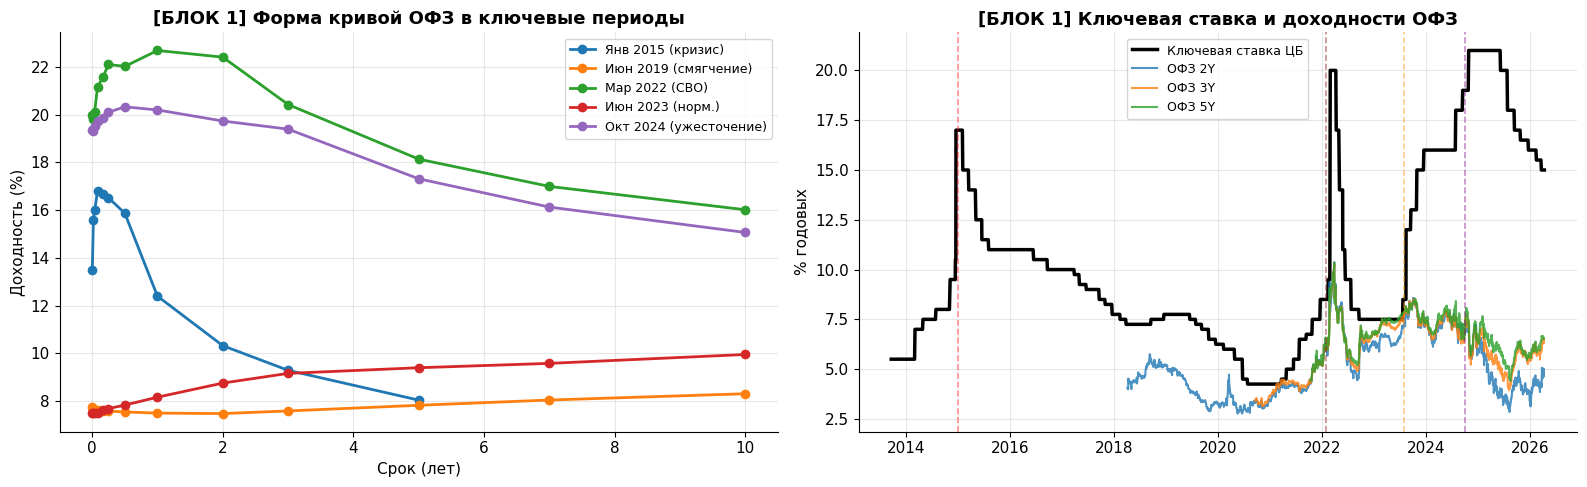

In [14]:
# БЛОК 1 | Обзор кривой ОФЗ
key_dates  = ['2015-01-30','2019-06-28','2022-03-31','2023-06-30','2024-10-31']
key_labels = ['Янв 2015 (кризис)','Июн 2019 (смягчение)','Мар 2022 (СВО)',
              'Июн 2023 (норм.)','Окт 2024 (ужесточение)']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Форма кривой по датам
for dt, lbl, c in zip(key_dates, key_labels, C):
    row  = df_yc.loc[df_yc.index.asof(pd.Timestamp(dt))]
    vals = pd.to_numeric(row, errors='coerce')
    axes[0].plot(tenor_years, vals.values, 'o-', label=lbl, color=c, lw=2)
axes[0].set_title('[БЛОК 1] Форма кривой ОФЗ в ключевые периоды', fontweight='bold')
axes[0].set_xlabel('Срок (лет)')
axes[0].set_ylabel('Доходность (%)')
axes[0].legend(fontsize=9)

# КС + ОФЗ 2/3/5Y
axes[1].plot(cbr_daily.index, cbr_daily['key_rate'], color='black', lw=2.5,
             label='Ключевая ставка ЦБ')
for col, lbl, c in zip(['OFZ_2Y','OFZ_3Y','OFZ_5Y'],
                        ['ОФЗ 2Y','ОФЗ 3Y','ОФЗ 5Y'], C):
    axes[1].plot(ofz_daily.index, ofz_daily[col], alpha=0.8, lw=1.5, label=lbl, color=c)
add_events(axes[1])
axes[1].set_title('[БЛОК 1] Ключевая ставка и доходности ОФЗ', fontweight='bold')
axes[1].set_ylabel('% годовых')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

[БЛОК 1 | PCA] Объяснённая дисперсия
  PC1: 97.81%  (накопл. 97.81%)
  PC2: 1.61%  (накопл. 99.42%)
  PC3: 0.52%  (накопл. 99.95%)
  PC4: 0.03%  (накопл. 99.98%)
  PC5: 0.01%  (накопл. 99.99%)


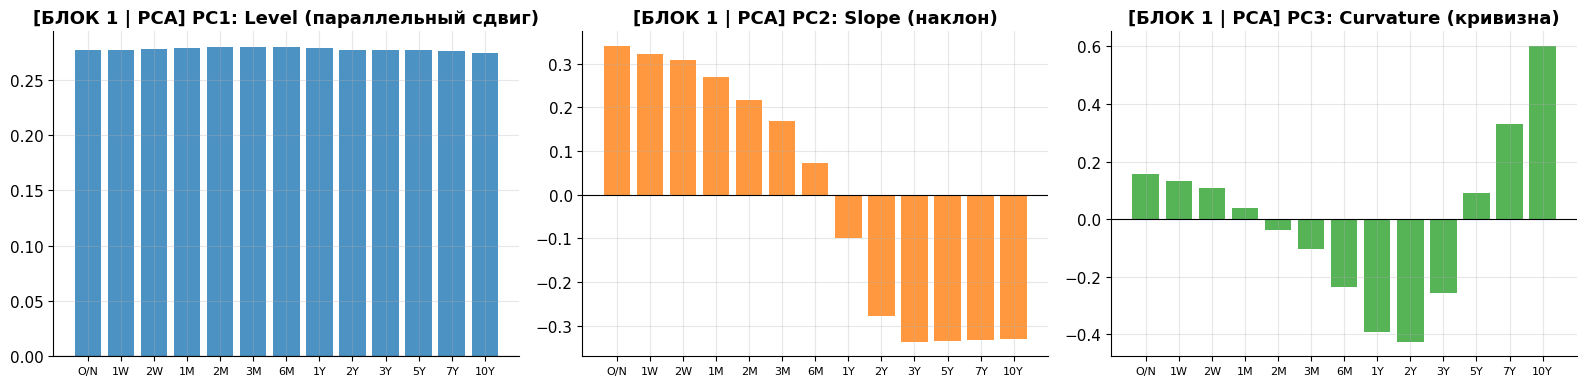

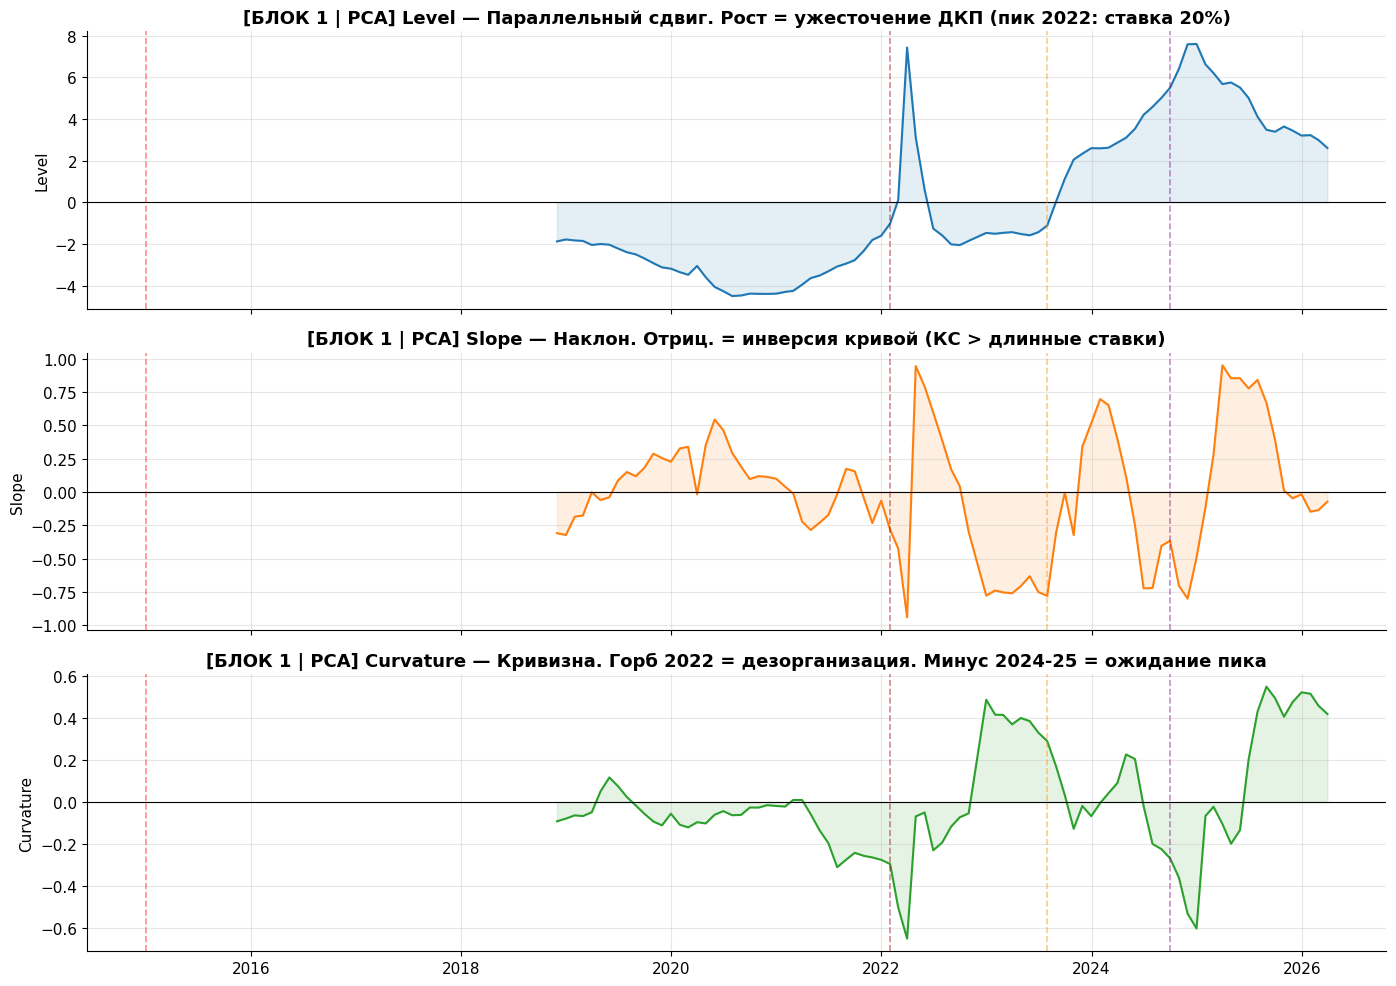

In [15]:
# БЛОК 1 | МЕТОД 1: PCA — Level / Slope / Curvature
yc_clean = df_yc.dropna()
yc_sc    = StandardScaler().fit_transform(yc_clean)
pca      = PCA(n_components=5)
F_pca    = pca.fit_transform(yc_sc)
ev       = pca.explained_variance_ratio_

print('[БЛОК 1 | PCA] Объяснённая дисперсия')
for i, e in enumerate(ev[:5]):
    print(f'  PC{i+1}: {e:.2%}  (накопл. {ev[:i+1].sum():.2%})')

factors_pca = pd.DataFrame(F_pca[:,:3], index=yc_clean.index,
                            columns=['Level','Slope','Curvature'])

# Нагрузки
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
pca_names = ['PC1: Level (параллельный сдвиг)',
             'PC2: Slope (наклон)',
             'PC3: Curvature (кривизна)']
for i, (ax, nm) in enumerate(zip(axes, pca_names)):
    ax.bar(range(len(tenors_avail)), pca.components_[i], color=C[i], alpha=0.8)
    ax.set_xticks(range(len(tenors_avail)))
    ax.set_xticklabels(tenors_avail, fontsize=8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'[БЛОК 1 | PCA] {nm}', fontweight='bold')
plt.tight_layout(); plt.show()

# Динамика факторов
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
narrative = {
    'Level':     'Параллельный сдвиг. Рост = ужесточение ДКП (пик 2022: ставка 20%)',
    'Slope':     'Наклон. Отриц. = инверсия кривой (КС > длинные ставки)',
    'Curvature': 'Кривизна. Горб 2022 = дезорганизация. Минус 2024-25 = ожидание пика'
}
for ax, col, c in zip(axes, factors_pca.columns, C):
    ax.plot(factors_pca.index, factors_pca[col], color=c, lw=1.5)
    ax.fill_between(factors_pca.index, factors_pca[col], alpha=0.12, color=c)
    ax.axhline(0, color='black', lw=0.8)
    add_events(ax)
    ax.set_ylabel(col)
    ax.set_title(f'[БЛОК 1 | PCA] {col} — {narrative[col]}', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

[БЛОК 1 | AR] Оптимальный лаг: AR(12), AIC=509.9


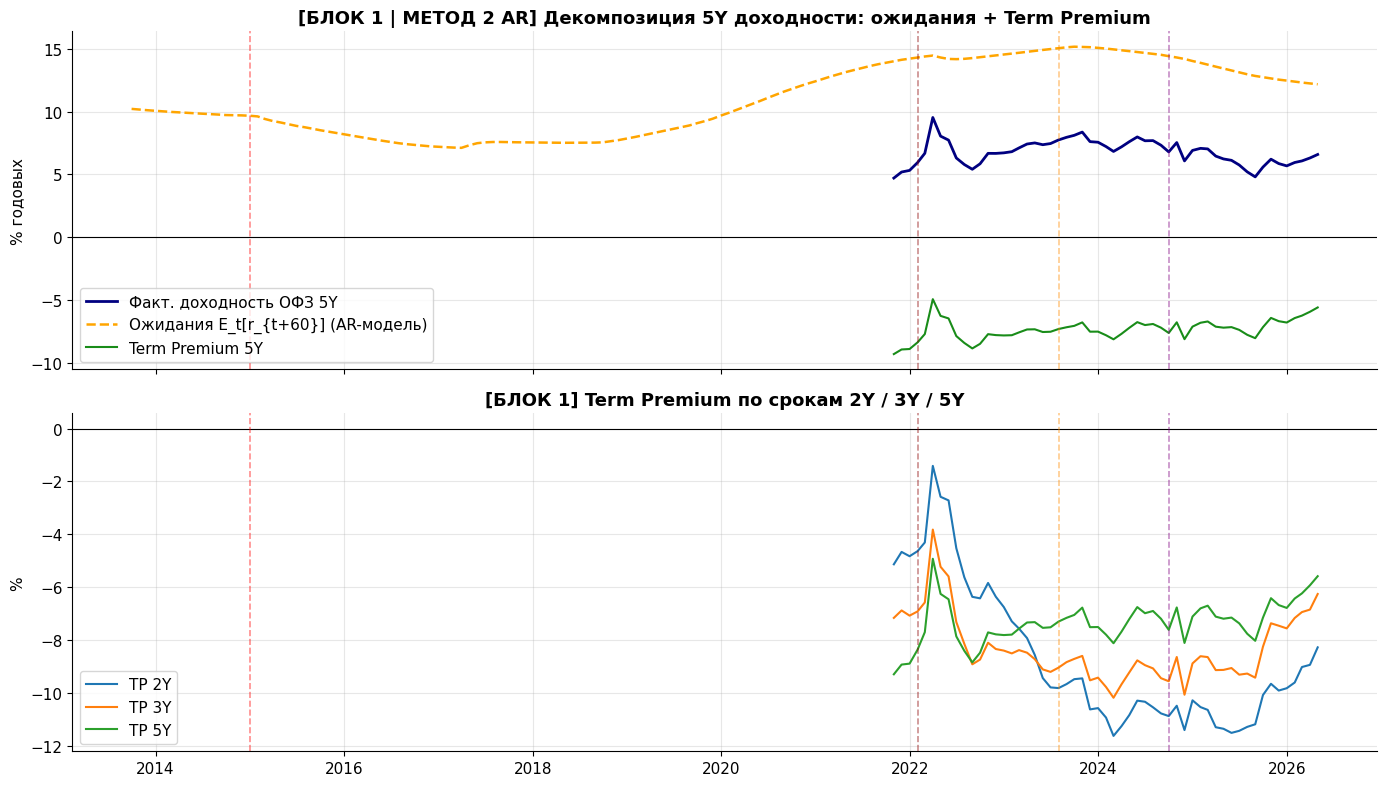

In [16]:
# БЛОК 1 | МЕТОД 2: AR-ожидания
# Ожидаемая средняя КС = среднее прогнозов AR(p) на h шагов вперёд
kr = cbr_m.dropna()

# Выбор лага AR по AIC
best_aic, best_lag = np.inf, 1
for lag in range(1, 13):
    try:
        m = AutoReg(kr, lags=lag, old_names=False).fit()
        if m.aic < best_aic: best_aic, best_lag = m.aic, lag
    except: pass
ar_model = AutoReg(kr, lags=best_lag, old_names=False).fit()
print(f'[БЛОК 1 | AR] Оптимальный лаг: AR({best_lag}), AIC={best_aic:.1f}')

def expected_rate(fit, series, h_months):
    """Средний прогноз AR на h_months шагов вперёд"""
    exp = []
    for t in range(len(series)):
        try: exp.append(fit.predict(start=t, end=t+h_months-1).mean())
        except: exp.append(np.nan)
    return pd.Series(exp, index=series.index)

exp_12 = expected_rate(ar_model, kr, 12)
exp_24 = expected_rate(ar_model, kr, 24)
exp_36 = expected_rate(ar_model, kr, 36)
exp_60 = expected_rate(ar_model, kr, 60)

# Term Premium = фактическая YTM - ожидаемая средняя ставка
tp_2y = (ofz_m['OFZ_2Y'] - exp_24).dropna()
tp_3y = (ofz_m['OFZ_3Y'] - exp_36).dropna()
tp_5y = (ofz_m['OFZ_5Y'] - exp_60).dropna()
tp_df  = pd.DataFrame({'TP_2Y': tp_2y, 'TP_3Y': tp_3y, 'TP_5Y': tp_5y}).dropna()

# График декомпозиции 5Y
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(ofz_m.index, ofz_m['OFZ_5Y'], lw=2, color='navy',
             label='Факт. доходность ОФЗ 5Y')
axes[0].plot(exp_60.index, exp_60, lw=1.8, ls='--', color='orange',
             label='Ожидания E_t[r_{t+60}] (AR-модель)')
axes[0].plot(tp_5y.index, tp_5y, lw=1.5, color='green', alpha=0.9,
             label='Term Premium 5Y')
axes[0].axhline(0, color='black', lw=0.8)
add_events(axes[0])
axes[0].set_title('[БЛОК 1 | МЕТОД 2 AR] Декомпозиция 5Y доходности: ожидания + Term Premium',
                  fontweight='bold')
axes[0].set_ylabel('% годовых')
axes[0].legend()

for col, lbl, c in zip(tp_df.columns, ['TP 2Y','TP 3Y','TP 5Y'], C):
    axes[1].plot(tp_df.index, tp_df[col], lw=1.5, label=lbl, color=c)
axes[1].axhline(0, color='black', lw=0.8)
add_events(axes[1])
axes[1].set_title('[БЛОК 1] Term Premium по срокам 2Y / 3Y / 5Y', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

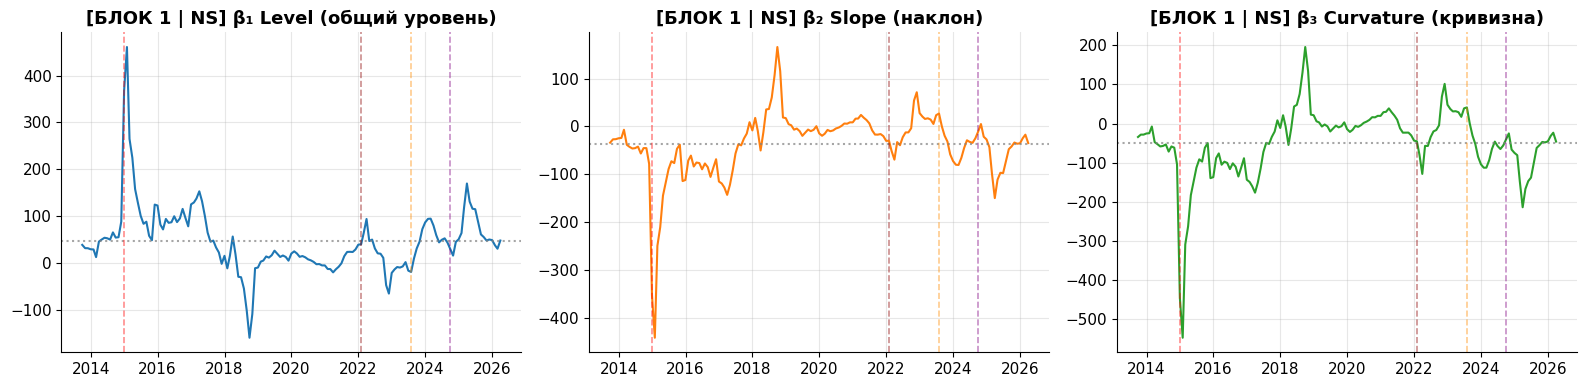

In [17]:
# БЛОК 1 | МЕТОД 3: Nelson–Siegel (динамический)
def ns_basis(tau, lam=0.0609):
    t  = np.array(tau, dtype=float)
    l2 = (1 - np.exp(-lam*t)) / (lam*t)
    l3 = l2 - np.exp(-lam*t)
    return np.column_stack([np.ones_like(t), l2, l3])

ns_cols = [c for c in ['1Y','2Y','3Y','5Y','7Y','10Y'] if c in df_yc.columns]
ns_tau  = [tenor_map[c] for c in ns_cols]
ns_betas = []
for dt, row in df_yc[ns_cols].iterrows():
    vals = row.values.astype(float)
    mask = ~np.isnan(vals)
    if mask.sum() >= 4:
        L = ns_basis(np.array(ns_tau)[mask])
        b, _, _, _ = np.linalg.lstsq(L, vals[mask], rcond=None)
    else:
        b = [np.nan]*3
    ns_betas.append({'date':dt, 'NS_b1':b[0], 'NS_b2':b[1], 'NS_b3':b[2]})
ns_df = pd.DataFrame(ns_betas).set_index('date').dropna()
ns_tp = (ns_df['NS_b1'] - exp_60.reindex(ns_df.index)).rename('NS_TP')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col, nm, c in zip(axes,
    ns_df.columns,
    ['β₁ Level (общий уровень)', 'β₂ Slope (наклон)', 'β₃ Curvature (кривизна)'],
    C):
    ax.plot(ns_df.index, ns_df[col], lw=1.5, color=c)
    ax.axhline(ns_df[col].mean(), color='gray', ls=':', alpha=0.7)
    add_events(ax)
    ax.set_title(f'[БЛОК 1 | NS] {nm}', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

[БЛОК 1 | CP] R² = 1.000


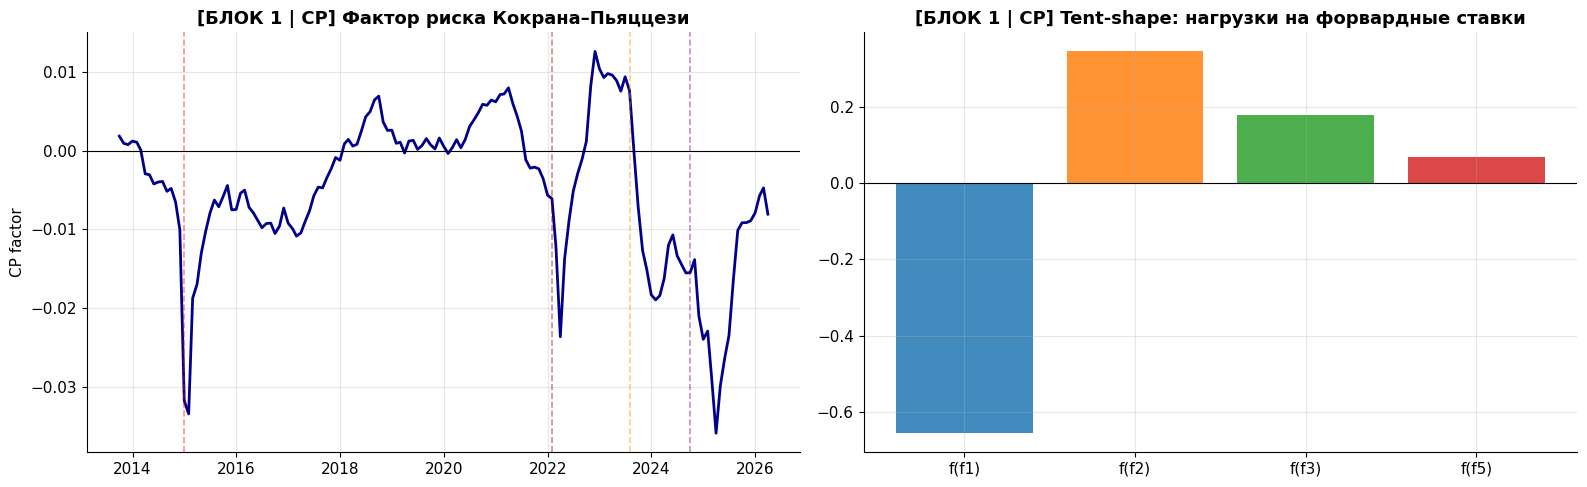

In [18]:
# БЛОК 1 | МЕТОД 4: Cochrane–Piazzesi (2005)
yc_m_dec = df_yc.apply(pd.to_numeric, errors='coerce').resample('ME').last() / 100

fwd = pd.DataFrame(index=yc_m_dec.index)
if '1Y' in yc_m_dec.columns: fwd['f1'] = yc_m_dec['1Y']
if '2Y' in yc_m_dec.columns and '1Y' in yc_m_dec.columns:
    fwd['f2'] = 2*yc_m_dec['2Y'] - yc_m_dec['1Y']
if '3Y' in yc_m_dec.columns and '2Y' in yc_m_dec.columns:
    fwd['f3'] = 3*yc_m_dec['3Y'] - 2*yc_m_dec['2Y']
if '5Y' in yc_m_dec.columns and '3Y' in yc_m_dec.columns:
    fwd['f5'] = 5*yc_m_dec['5Y'] - 3*yc_m_dec['3Y']
fwd = fwd.dropna()

rx_cols = [c for c in ['2Y','3Y','5Y'] if c in yc_m_dec.columns]
rx_avg  = pd.DataFrame({c: yc_m_dec[c]-yc_m_dec['1Y']
                        for c in rx_cols if '1Y' in yc_m_dec.columns}).mean(axis=1)

idx_cp = fwd.index.intersection(rx_avg.dropna().index)
cp_reg = sm.OLS(rx_avg.loc[idx_cp],
                sm.add_constant(fwd.loc[idx_cp])).fit(
    cov_type='HAC', cov_kwds={'maxlags':12})
cp_factor = cp_reg.fittedvalues

print(f'[БЛОК 1 | CP] R² = {cp_reg.rsquared:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(cp_factor.index, cp_factor, lw=2, color='darkblue')
axes[0].axhline(0, color='black', lw=0.8)
add_events(axes[0])
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[0].set_title('[БЛОК 1 | CP] Фактор риска Кокрана–Пьяццези', fontweight='bold')
axes[0].set_ylabel('CP factor')

gamma = cp_reg.params[1:]
axes[1].bar(range(len(gamma)), gamma.values, color=C[:len(gamma)], alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(range(len(gamma)))
axes[1].set_xticklabels([f'f({n})' for n in fwd.columns])
axes[1].set_title('[БЛОК 1 | CP] Tent-shape: нагрузки на форвардные ставки',
                  fontweight='bold')
plt.tight_layout(); plt.show()

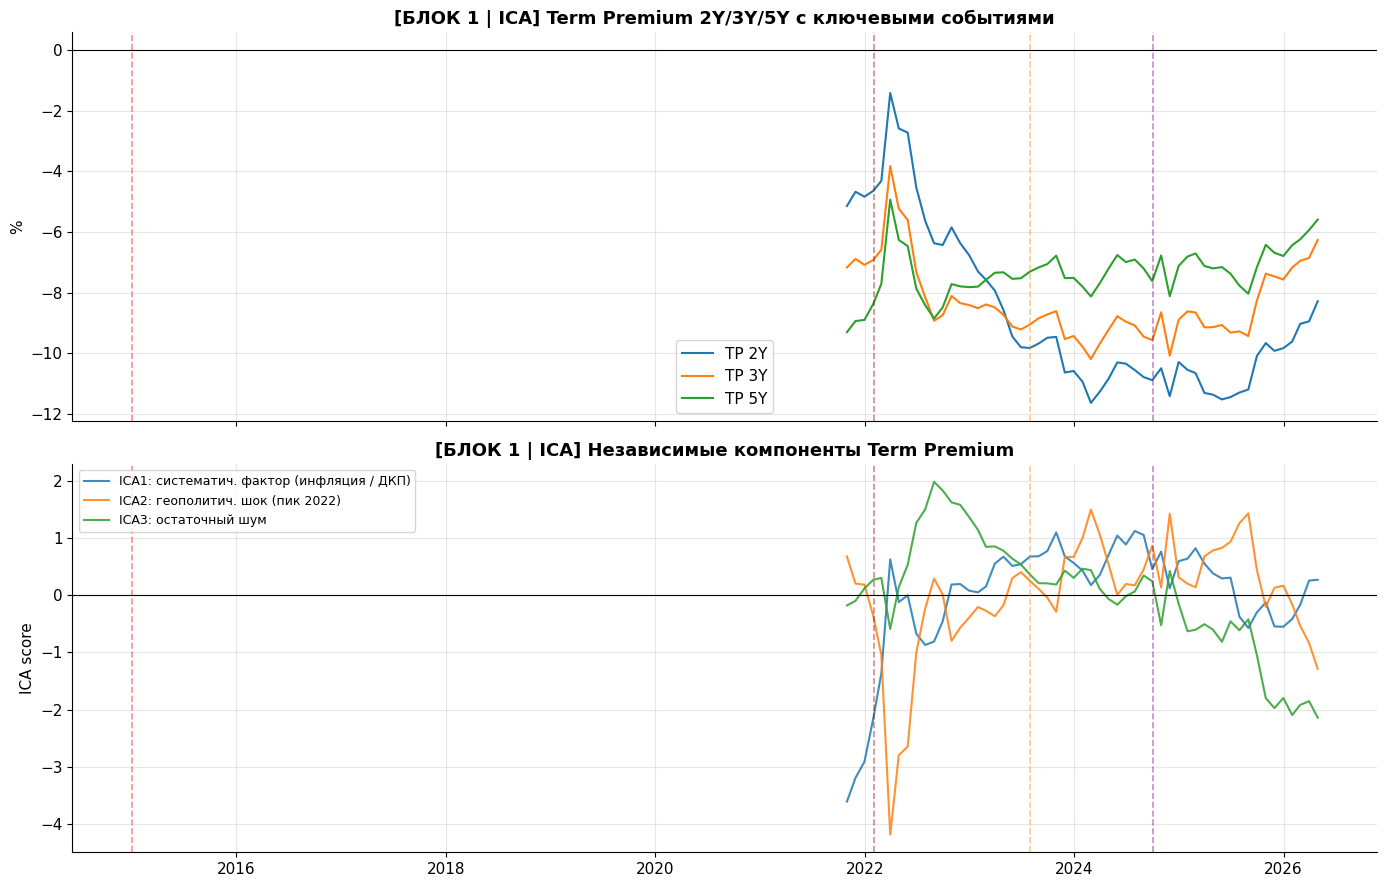

In [19]:
# БЛОК 1 | ICA: независимые компоненты Term Premium
ica    = FastICA(n_components=3, random_state=42, max_iter=1000)
ica_F  = ica.fit_transform(tp_df.dropna())
ica_df = pd.DataFrame(ica_F, index=tp_df.dropna().index,
                      columns=['ICA1','ICA2','ICA3'])

ica_interp = {
    'ICA1': 'систематич. фактор (инфляция / ДКП)',
    'ICA2': 'геополитич. шок (пик 2022)',
    'ICA3': 'остаточный шум'
}

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
for col, lbl, c in zip(tp_df.columns, ['TP 2Y','TP 3Y','TP 5Y'], C):
    axes[0].plot(tp_df.index, tp_df[col], lw=1.5, label=lbl, color=c)
axes[0].axhline(0, color='black', lw=0.8)
add_events(axes[0])
axes[0].set_title('[БЛОК 1 | ICA] Term Premium 2Y/3Y/5Y с ключевыми событиями',
                  fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend()

for col, c in zip(ica_df.columns, C[:3]):
    axes[1].plot(ica_df.index, ica_df[col], lw=1.5,
                 label=f'{col}: {ica_interp[col]}', color=c, alpha=0.85)
axes[1].axhline(0, color='black', lw=0.8)
add_events(axes[1])
axes[1].set_title('[БЛОК 1 | ICA] Независимые компоненты Term Premium',
                  fontweight='bold')
axes[1].set_ylabel('ICA score')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

[БЛОК 1] Описательная статистика
             mean     std      min      max  skewness  kurtosis
TP_2Y      -8.722   2.715  -11.634   -1.413     1.055     0.030
TP_3Y      -8.342   1.261  -10.189   -3.825     1.372     2.323
TP_5Y      -7.370   0.805   -9.302   -4.930     0.057     0.991
Level       2.127   3.063   -2.339    7.603     0.043    -1.246
Slope      -0.048   0.563   -0.942    0.951     0.251    -1.107
Curvature   0.045   0.323   -0.649    0.549    -0.112    -0.892
NS_b1      45.990  42.310  -46.660  169.933     0.429     0.600
NS_b2     -32.146  39.140 -149.956   54.228    -0.512     0.757
NS_b3     -49.716  57.972 -213.556   68.643    -0.322     0.404

[БЛОК 1] Тест ADF на стационарность
          ADF-stat   p-val  I(0)?
TP_2Y       -1.404  0.5803  Нет ✗
TP_3Y       -1.942  0.3127  Нет ✗
TP_5Y       -3.478  0.0086   Да ✓
Level       -1.878  0.3424  Нет ✗
Slope       -2.637  0.0857  Нет ✗
Curvature   -2.167  0.2183  Нет ✗
NS_b1       -2.248  0.1893  Нет ✗
NS_b2       -2.377

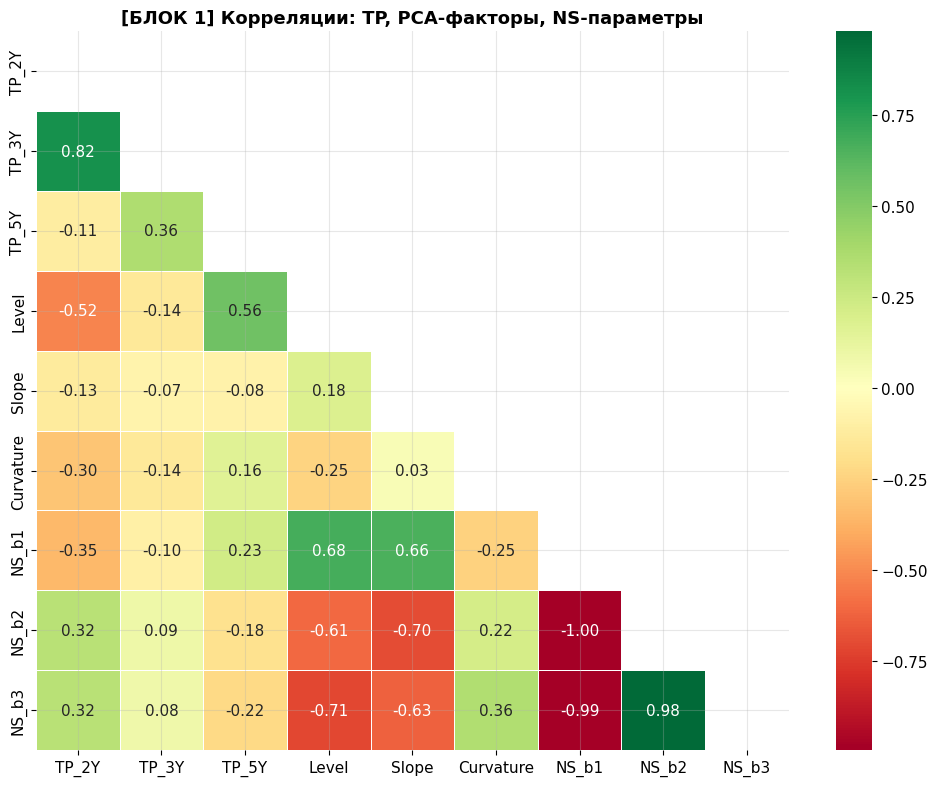

In [20]:
# БЛОК 1 | Описательная статистика + ADF
all_series = pd.concat([tp_df, factors_pca, ns_df[['NS_b1','NS_b2','NS_b3']]], axis=1).dropna()

desc = all_series.describe().T
desc['skewness'] = all_series.skew()
desc['kurtosis'] = all_series.kurt()

adf_res = {}
for col in all_series.columns:
    r = adfuller(all_series[col].dropna())
    adf_res[col] = {'ADF-stat': round(r[0],3), 'p-val': round(r[1],4),
                    'I(0)?': 'Да ✓' if r[1]<0.05 else 'Нет ✗'}

print('[БЛОК 1] Описательная статистика')
print(desc[['mean','std','min','max','skewness','kurtosis']].round(3).to_string())
print()
print('[БЛОК 1] Тест ADF на стационарность')
print(pd.DataFrame(adf_res).T.to_string())

# Корреляционная матрица
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(all_series.corr(), annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=np.triu(np.ones_like(all_series.corr(), dtype=bool)),
            ax=ax, linewidths=0.5)
ax.set_title('[БЛОК 1] Корреляции: TP, PCA-факторы, NS-параметры', fontweight='bold')
plt.tight_layout(); plt.show()

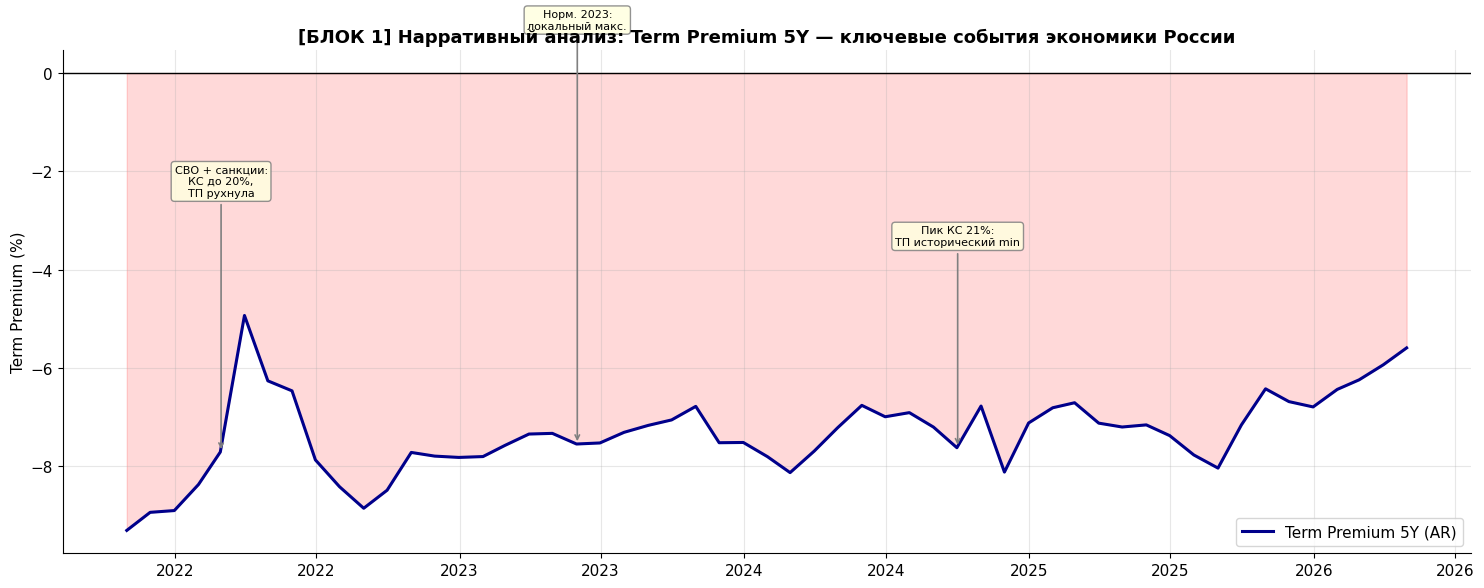

In [21]:
# БЛОК 1 | Нарративный анализ TP 5Y
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(tp_5y.index, tp_5y, lw=2.2, color='darkblue', label='Term Premium 5Y (AR)')
ax.fill_between(tp_5y.index, tp_5y, 0, where=tp_5y<0, alpha=0.15, color='red')
ax.fill_between(tp_5y.index, tp_5y, 0, where=tp_5y>0, alpha=0.15, color='green')
ax.axhline(0, color='black', lw=1)

annotations = [
    ('2015-01', -4.0, 'Кризис 2015:\nКС до 17%,\nинверсия кривой'),
    ('2017-06', 0.5,  'Цикл смягчения\n2016–2019:\nТП растёт к 0'),
    ('2020-04', -1.2, 'COVID-19:\nсмягчение ДКП'),
    ('2022-03', -2.5, 'СВО + санкции:\nКС до 20%,\nТП рухнула'),
    ('2023-06', 0.9,  'Норм. 2023:\nлокальный макс.'),
    ('2024-10', -3.5, 'Пик КС 21%:\nТП исторический min'),
]
for dt, ypos, txt in annotations:
    x = pd.Timestamp(dt)
    try: yactual = tp_5y.asof(x)
    except: yactual = 0
    ax.annotate(txt, xy=(x, yactual), xytext=(x, ypos),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2),
                fontsize=8, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray', alpha=0.85))

ax.set_title('[БЛОК 1] Нарративный анализ: Term Premium 5Y — ключевые события экономики России',
             fontweight='bold')
ax.set_ylabel('Term Premium (%)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
plt.tight_layout(); plt.show()

[БЛОК 1] Корреляция TP Россия–США: 0.537
[БЛОК 1] Средний спред Россия–США: -7.681%


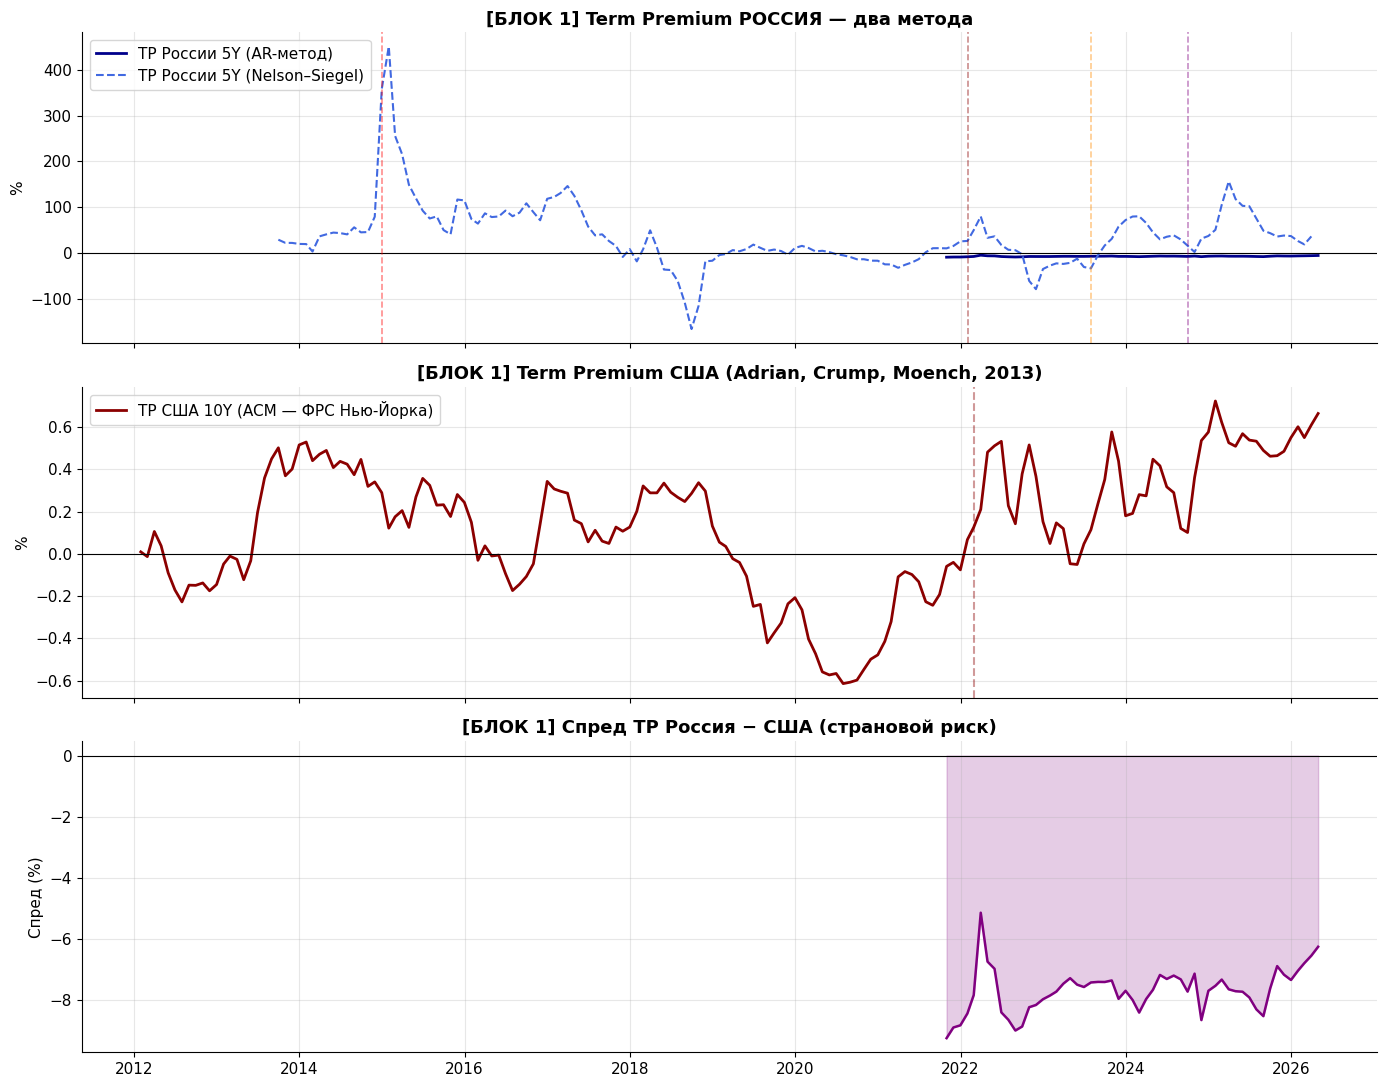

In [22]:
# БЛОК 1 | Сравнение с международным опытом: Россия vs США
tp5_m   = tp_5y.resample('ME').mean()
us_tp_m = tp_us_m['US_TP_10Y'].dropna()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

# Россия — два метода
axes[0].plot(tp5_m.index, tp5_m, lw=2, color='darkblue', label='TP России 5Y (AR-метод)')
axes[0].plot(ns_tp.index, ns_tp, lw=1.5, ls='--', color='royalblue',
             label='TP России 5Y (Nelson–Siegel)')
axes[0].axhline(0, color='black', lw=0.8)
add_events(axes[0])
axes[0].set_title('[БЛОК 1] Term Premium РОССИЯ — два метода', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].legend()

# США — ACM
axes[1].plot(us_tp_m.index, us_tp_m, lw=2, color='darkred',
             label='TP США 10Y (ACM — ФРС Нью-Йорка)')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].axvline(pd.Timestamp('2022-03'), color='darkred', ls='--', alpha=0.4)
axes[1].set_title('[БЛОК 1] Term Premium США (Adrian, Crump, Moench, 2013)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend()

# Спред Россия – США
common = tp5_m.index.intersection(us_tp_m.index)
spread = tp5_m.loc[common] - us_tp_m.loc[common]
axes[2].plot(spread.index, spread, lw=1.8, color='purple')
axes[2].fill_between(spread.index, spread, 0, alpha=0.2, color='purple')
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('[БЛОК 1] Спред TP Россия − США (страновой риск)', fontweight='bold')
axes[2].set_ylabel('Спред (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

corr_val = tp5_m.loc[common].corr(us_tp_m.loc[common])
print(f'[БЛОК 1] Корреляция TP Россия–США: {corr_val:.3f}')
print(f'[БЛОК 1] Средний спред Россия–США: {spread.mean():.3f}%')
plt.tight_layout(); plt.show()

---
# БЛОК 2. Тестирование прогнозной силы ожиданий
> **[50 баллов + до 25 дополнительных]**
>
> **Целевые переменные y_{t+h}:** ключевая ставка, ИПЦ (инфляция), REER, разрыв выпуска.  
> **M1:** y = α + β·E_t[r_{t+h}] + γ·X_t (с ожиданиями)  
> **M2:** y = α̃ + γ̃·X_t (без ожиданий)  
> **M3:** E_t r_{t+h} → форвардная кривая f(t,t+h)

In [23]:
# БЛОК 2 | Подготовка всех целевых переменных

# 1. Контрольные переменные X_t
controls = pd.DataFrame({
    'key_rate_L1':  cbr_m.shift(1),
    'key_rate_L2':  cbr_m.shift(2),
    'cpi_yoy_L1':   cpi['CPI_yoy'].resample('ME').last().shift(1),
    'tp5y_L1':      tp_5y.resample('ME').mean().shift(1),
    'slope_L1':     (ofz_m['OFZ_5Y'] - cbr_m.reindex(ofz_m.index)).shift(1),
    'reer_yoy_L1':  reer_yoy.resample('ME').last().shift(1),
}).dropna()

# 2. Форвардные ставки как альтернативные предикторы
fwd_3y_pct = fwd.get('f3', fwd.iloc[:, 0]).rename('fwd_3y') * 100
fwd_5y_pct = fwd.get('f5', fwd.iloc[:, -1]).rename('fwd_5y') * 100

# 3. Целевые переменные
targets = {
    'Ключевая ставка':   cbr_m,
    'ИПЦ YoY (%)':       cpi['CPI_yoy'].resample('ME').last(),
    'REER (уровень)':    reer_level.resample('ME').last(),
    'Разрыв выпуска':    output_gap_m,
}

# 4. Вывод информации по целевым переменным
print('[БЛОК 2] Целевые переменные:')

for nm, s in targets.items():
    sd = s.dropna()

    if len(sd) == 0:
        print(f'  {nm:<25} ПУСТАЯ СЕРИЯ')
    else:
        print(
            f'  {nm:<25} '
            f'{str(sd.index[0].date()):>12} — {str(sd.index[-1].date()):<12} '
            f'n={len(sd)}'
        )

[БЛОК 2] Целевые переменные:
  Ключевая ставка             2013-09-30 — 2026-04-30   n=152
  ИПЦ YoY (%)                 1992-02-29 — 2026-03-31   n=410
  REER (уровень)              2010-01-31 — 2026-02-28   n=194
  Разрыв выпуска              2011-01-31 — 2025-09-30   n=177


In [24]:

# ============================================================
# БЛОК 2 | Корректное сравнение прогнозных регрессий
# ============================================================

def _blank_result_row(h, status, n=None, label='exp'):
    row = {
        'h(мес)': h,
        'n': int(n) if n is not None and not pd.isna(n) else pd.NA,
        'статус': status
    }
    if label == 'exp':
        row.update({
            'RMSE M1 (с ожид.)': pd.NA,
            'RMSE M2 (без)': pd.NA,
            'ΔRMSE (%)': pd.NA,
            'β(exp)': pd.NA,
            'p(β)': pd.NA,
            'DM p-val': pd.NA,
            'R² M1': pd.NA,
            'R² M2': pd.NA,
        })
    else:
        row.update({
            'RMSE M1 (с форв.)': pd.NA,
            'RMSE M2 (без)': pd.NA,
            'ΔRMSE (%)': pd.NA,
            'β(fwd)': pd.NA,
            'p(β)': pd.NA,
            'DM p-val': pd.NA,
            'R² M1': pd.NA,
            'R² M2': pd.NA,
        })
    return row

def _fit_safe_ols(y, X, hac_lags):
    df = pd.concat([pd.Series(y, name='y'), pd.DataFrame(X)], axis=1).dropna()
    if len(df) < 8:
        return None, df
    y_clean = df['y']
    X_clean = sm.add_constant(df.drop(columns='y'), has_constant='add')
    if X_clean.shape[1] >= len(df):
        return None, df
    model = sm.OLS(y_clean, X_clean).fit(cov_type='HAC', cov_kwds={'maxlags': max(1, min(hac_lags, len(df)//3))})
    return model, df

def forecast_compare_by_horizon(y_target, exp_dict, controls_df,
                                fwd_dict=None, horizons=[12, 24, 36],
                                min_obs=24):
    """
    Сравнение:
    M1: y_{t+h} ~ E_t[r_{t+h}] + X_t
    M2: y_{t+h} ~ X_t

    exp_dict: словарь ожиданий по горизонту, например:
        {12: exp_12, 24: exp_24, 36: exp_36}

    fwd_dict: словарь форвардов по горизонту, например:
        {12: fwd_1y, 24: fwd_2y, 36: fwd_3y}
    """
    rows_exp = []
    rows_fwd = []

    controls_clean = controls_df.copy()
    if not isinstance(controls_clean.index, pd.DatetimeIndex):
        controls_clean.index = pd.to_datetime(controls_clean.index)

    for h in horizons:
        y_fwd = y_target.shift(-h).dropna()

        # ---------- ожидания ----------
        exp_ser = exp_dict.get(h, None)
        if exp_ser is None:
            rows_exp.append(_blank_result_row(h, 'нет ожиданий', label='exp'))
        else:
            idx = y_fwd.index.intersection(exp_ser.dropna().index).intersection(controls_clean.index)
            df_exp = pd.concat([
                y_fwd.loc[idx].rename('y'),
                exp_ser.loc[idx].rename('E_rate'),
                controls_clean.loc[idx]
            ], axis=1).dropna()

            if len(df_exp) < min_obs:
                rows_exp.append(_blank_result_row(h, f'мало данных (n={len(df_exp)})', n=len(df_exp), label='exp'))
            else:
                m1, df1 = _fit_safe_ols(df_exp['y'], df_exp[['E_rate'] + list(controls_clean.columns)], hac_lags=h)
                m2, df2 = _fit_safe_ols(df_exp['y'], df_exp[list(controls_clean.columns)], hac_lags=h)

                if (m1 is None) or (m2 is None):
                    rows_exp.append(_blank_result_row(h, f'неустойчивая регрессия (n={len(df_exp)})', n=len(df_exp), label='exp'))
                else:
                    common_idx = df1.index.intersection(df2.index)
                    y = df_exp.loc[common_idx, 'y']
                    fit1 = m1.predict(sm.add_constant(df_exp.loc[common_idx, ['E_rate'] + list(controls_clean.columns)], has_constant='add'))
                    fit2 = m2.predict(sm.add_constant(df_exp.loc[common_idx, list(controls_clean.columns)], has_constant='add'))

                    rmse1 = float(np.sqrt(mean_squared_error(y, fit1)))
                    rmse2 = float(np.sqrt(mean_squared_error(y, fit2)))

                    d = (y - fit2) ** 2 - (y - fit1) ** 2
                    if len(d) > 3 and float(d.std(ddof=1)) > 0:
                        dm_t = float(d.mean() / (d.std(ddof=1) / np.sqrt(len(d))))
                        dm_p = float(2 * (1 - stats.norm.cdf(abs(dm_t))))
                    else:
                        dm_p = np.nan

                    rows_exp.append({
                        'h(мес)': h,
                        'n': int(len(common_idx)),
                        'RMSE M1 (с ожид.)': round(rmse1, 4),
                        'RMSE M2 (без)': round(rmse2, 4),
                        'ΔRMSE (%)': round((rmse2 - rmse1) / rmse2 * 100, 2) if rmse2 != 0 else pd.NA,
                        'β(exp)': round(float(m1.params.get('E_rate', np.nan)), 4),
                        'p(β)': round(float(m1.pvalues.get('E_rate', np.nan)), 4),
                        'DM p-val': round(dm_p, 4) if pd.notna(dm_p) else pd.NA,
                        'R² M1': round(float(m1.rsquared), 3),
                        'R² M2': round(float(m2.rsquared), 3),
                        'статус': 'ok'
                    })

        # ---------- форварды ----------
        if fwd_dict is not None:
            fwd_ser = fwd_dict.get(h, None)
            if fwd_ser is None:
                rows_fwd.append(_blank_result_row(h, 'нет форварда', label='fwd'))
            else:
                idx = y_fwd.index.intersection(fwd_ser.dropna().index).intersection(controls_clean.index)
                df_fwd = pd.concat([
                    y_fwd.loc[idx].rename('y'),
                    fwd_ser.loc[idx].rename('F_rate'),
                    controls_clean.loc[idx]
                ], axis=1).dropna()

                if len(df_fwd) < min_obs:
                    rows_fwd.append(_blank_result_row(h, f'мало данных (n={len(df_fwd)})', n=len(df_fwd), label='fwd'))
                else:
                    m1, df1 = _fit_safe_ols(df_fwd['y'], df_fwd[['F_rate'] + list(controls_clean.columns)], hac_lags=h)
                    m2, df2 = _fit_safe_ols(df_fwd['y'], df_fwd[list(controls_clean.columns)], hac_lags=h)

                    if (m1 is None) or (m2 is None):
                        rows_fwd.append(_blank_result_row(h, f'неустойчивая регрессия (n={len(df_fwd)})', n=len(df_fwd), label='fwd'))
                    else:
                        common_idx = df1.index.intersection(df2.index)
                        y = df_fwd.loc[common_idx, 'y']
                        fit1 = m1.predict(sm.add_constant(df_fwd.loc[common_idx, ['F_rate'] + list(controls_clean.columns)], has_constant='add'))
                        fit2 = m2.predict(sm.add_constant(df_fwd.loc[common_idx, list(controls_clean.columns)], has_constant='add'))

                        rmse1 = float(np.sqrt(mean_squared_error(y, fit1)))
                        rmse2 = float(np.sqrt(mean_squared_error(y, fit2)))

                        d = (y - fit2) ** 2 - (y - fit1) ** 2
                        if len(d) > 3 and float(d.std(ddof=1)) > 0:
                            dm_t = float(d.mean() / (d.std(ddof=1) / np.sqrt(len(d))))
                            dm_p = float(2 * (1 - stats.norm.cdf(abs(dm_t))))
                        else:
                            dm_p = np.nan

                        rows_fwd.append({
                            'h(мес)': h,
                            'n': int(len(common_idx)),
                            'RMSE M1 (с форв.)': round(rmse1, 4),
                            'RMSE M2 (без)': round(rmse2, 4),
                            'ΔRMSE (%)': round((rmse2 - rmse1) / rmse2 * 100, 2) if rmse2 != 0 else pd.NA,
                            'β(fwd)': round(float(m1.params.get('F_rate', np.nan)), 4),
                            'p(β)': round(float(m1.pvalues.get('F_rate', np.nan)), 4),
                            'DM p-val': round(dm_p, 4) if pd.notna(dm_p) else pd.NA,
                            'R² M1': round(float(m1.rsquared), 3),
                            'R² M2': round(float(m2.rsquared), 3),
                            'статус': 'ok'
                        })

    return pd.DataFrame(rows_exp), pd.DataFrame(rows_fwd)


In [25]:
# ============================================================
# БЛОК 2 | Словарь ожиданий по горизонтам
# ============================================================

exp_dict = {
    12: exp_12,
    24: exp_24,
    36: exp_36,
}

In [26]:
# ============================================================
# БЛОК 2 | Словарь форвардных ставок по горизонтам
# ============================================================

fwd_dict = {
    12: fwd.get('f1', fwd.iloc[:, 0]).resample('ME').last() * 100,
    24: fwd.get('f2', fwd.iloc[:, 1]).resample('ME').last() * 100,
    36: fwd.get('f3', fwd.iloc[:, 2]).resample('ME').last() * 100,
}

In [27]:
results_ar = {}
results_fwd = {}

for name, y_ser in targets.items():
    print('\n' + '=' * 55)
    print(f'[БЛОК 2] Цель: {name}')
    print('=' * 55)

    r_exp, r_fwd = forecast_compare_by_horizon(
        y_target=y_ser,
        exp_dict=exp_dict,
        controls_df=controls,
        fwd_dict=fwd_dict,
        horizons=[12, 24, 36],
        min_obs=24
    )

    results_ar[name] = r_exp
    results_fwd[name] = r_fwd

    print('--- Ожидания ---')
    print(r_exp.fillna('—').to_string(index=False))

    print('--- Форварды ---')
    print(r_fwd.fillna('—').to_string(index=False))


[БЛОК 2] Цель: Ключевая ставка
--- Ожидания ---
 h(мес)  n RMSE M1 (с ожид.) RMSE M2 (без) ΔRMSE (%)  β(exp)    p(β) DM p-val  R² M1  R² M2             статус
     12 42            2.1171        2.5166     15.87  0.9969   0.008   0.0216  0.787  0.699                 ok
     24 30            0.7683        0.7698       0.2 -0.1311  0.5498   0.8117  0.882  0.882                 ok
     36 18                 —             —         —       —       —        —      —      — мало данных (n=18)
--- Форварды ---
 h(мес)  n RMSE M1 (с форв.) RMSE M2 (без) ΔRMSE (%)  β(fwd)    p(β) DM p-val  R² M1  R² M2             статус
     12 42            2.5164        2.5166      0.01  0.0215  0.9567    0.976  0.699  0.699                 ok
     24 30            0.7582        0.7698      1.51 -0.1547  0.3651   0.6929  0.885  0.882                 ok
     36 18                 —             —         —       —       —        —      —      — мало данных (n=18)

[БЛОК 2] Цель: ИПЦ YoY (%)
--- Ожидания ---
 

In [28]:
# ============================================================
# БЛОК 2 | ЧИСТАЯ СВОДНАЯ ТАБЛИЦА
# ============================================================

print('=== [БЛОК 2] ИТОГОВОЕ СРАВНЕНИЕ ===')

rows_sum = []

for name in targets.keys():
    r_ar  = results_ar.get(name)
    r_fwd = results_fwd.get(name)

    if r_ar is None:
        continue

    for _, row_ar in r_ar.iterrows():
        h = row_ar['h(мес)']

        # форвард для того же горизонта
        row_fwd = None
        if r_fwd is not None:
            tmp = r_fwd[r_fwd['h(мес)'] == h]
            if len(tmp) > 0:
                row_fwd = tmp.iloc[0]

        rows_sum.append({
            'Переменная': name,
            'h': h,

            # AR
            'ΔRMSE AR (%)': row_ar.get('ΔRMSE (%)'),
            'β(exp)':       row_ar.get('β(exp)'),
            'p(β)':         row_ar.get('p(β)'),

            # Forward
            'ΔRMSE Fwd (%)': row_fwd.get('ΔRMSE (%)') if row_fwd is not None else np.nan,
            'β(fwd)':        row_fwd.get('β(fwd)') if row_fwd is not None else np.nan,
            'p(β fwd)':      row_fwd.get('p(β)') if row_fwd is not None else np.nan,

            # статус
            'Статус AR':  row_ar.get('статус'),
            'Статус Fwd': row_fwd.get('статус') if row_fwd is not None else None,
        })

summary_df = pd.DataFrame(rows_sum)
summary_df = summary_df.sort_values(['Переменная', 'h'])

print(summary_df.fillna('—').to_string(index=False))

=== [БЛОК 2] ИТОГОВОЕ СРАВНЕНИЕ ===
     Переменная  h ΔRMSE AR (%)  β(exp)    p(β) ΔRMSE Fwd (%)  β(fwd) p(β fwd)          Статус AR         Статус Fwd
 REER (уровень) 12        13.53  2.2616  0.0015          1.38  0.9004   0.3118                 ok                 ok
 REER (уровень) 24         9.43  5.4455     0.0          0.01  0.0437   0.9146                 ok                 ok
 REER (уровень) 36            —       —       —             —       —        — мало данных (n=16) мало данных (n=16)
    ИПЦ YoY (%) 12        18.92  0.5437     0.0          1.07  0.1588   0.1292                 ok                 ok
    ИПЦ YoY (%) 24         0.19  0.0953  0.5996          0.06  0.0187   0.8329                 ok                 ok
    ИПЦ YoY (%) 36            —       —       —             —       —        — мало данных (n=17) мало данных (n=17)
Ключевая ставка 12        15.87  0.9969   0.008          0.01  0.0215   0.9567                 ok                 ok
Ключевая ставка 24          

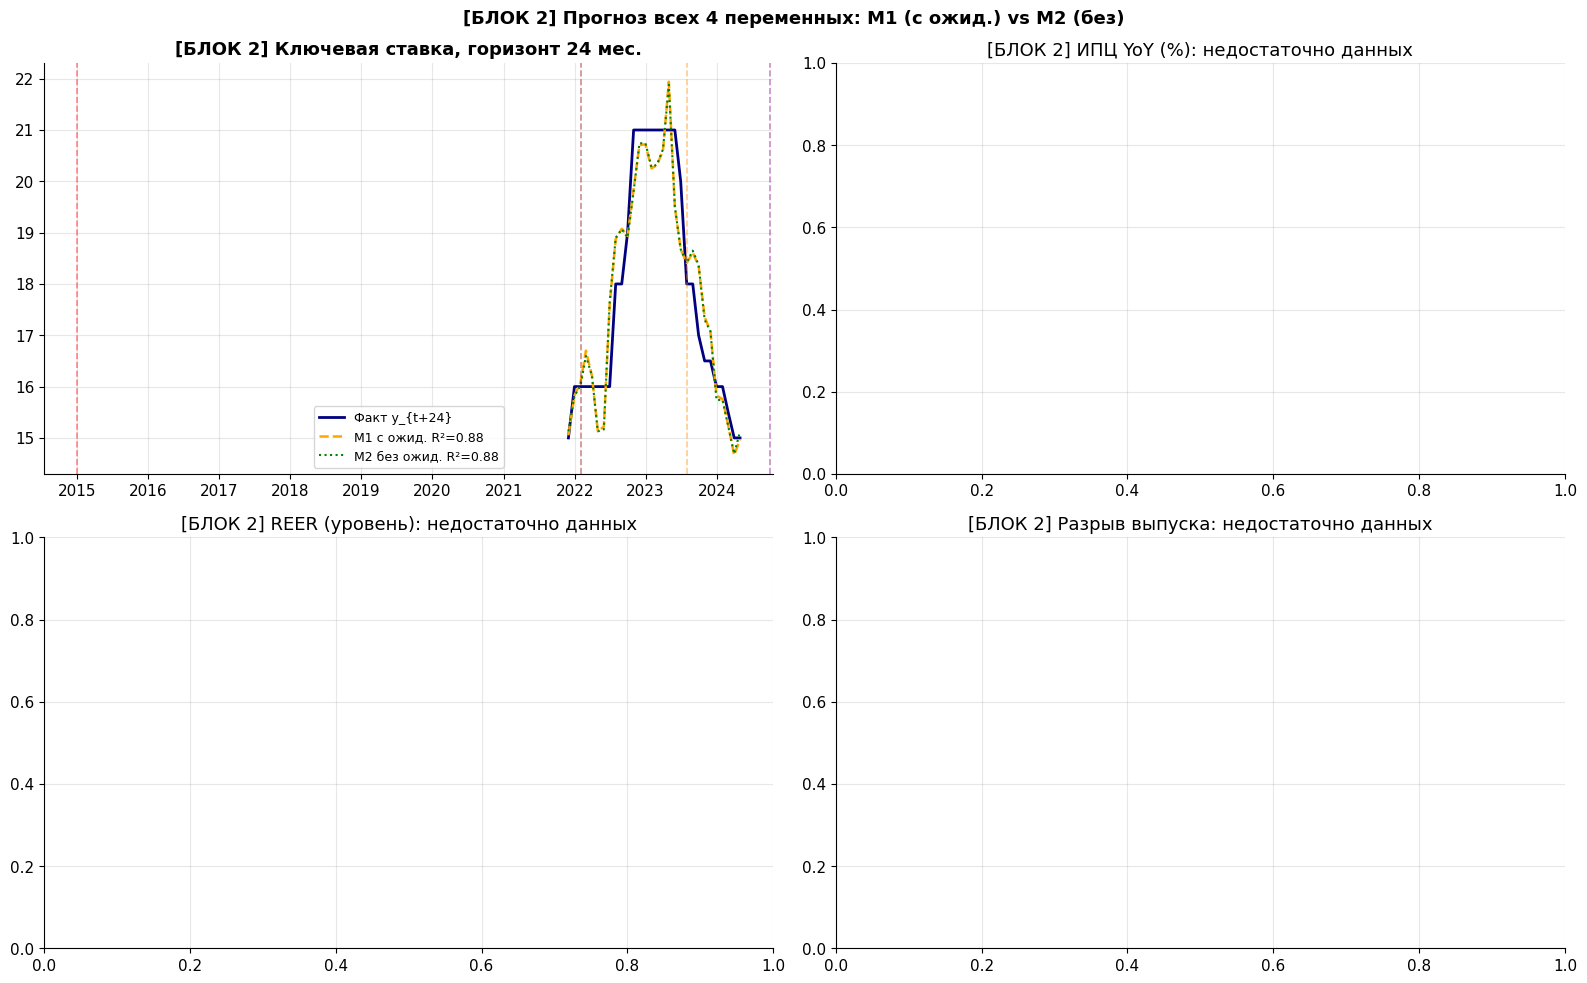

In [29]:
# БЛОК 2 | Графики прогнозов для всех 4 переменных (горизонт 24 мес)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (name, y_ser) in zip(axes.flat, targets.items()):
    h   = 24
    y_f = y_ser.shift(-h).dropna()
    idx = (y_f.index.intersection(exp_24.dropna().index)
                    .intersection(controls.dropna().index))
    if len(idx) < 30:
        ax.set_title(f'[БЛОК 2] {name}: недостаточно данных'); continue

    X1 = sm.add_constant(pd.concat([exp_24.loc[idx].rename('E_rate'),
                                     controls.loc[idx]], axis=1))
    m1 = sm.OLS(y_f.loc[idx], X1).fit()
    X2 = sm.add_constant(controls.loc[idx])
    m2 = sm.OLS(y_f.loc[idx], X2).fit()

    ax.plot(y_f.loc[idx].index, y_f.loc[idx].values, lw=2, color='navy',
            label='Факт y_{t+24}')
    ax.plot(m1.fittedvalues.index, m1.fittedvalues.values, lw=1.8,
            ls='--', color='orange',
            label=f'M1 с ожид. R²={m1.rsquared:.2f}')
    ax.plot(m2.fittedvalues.index, m2.fittedvalues.values, lw=1.5,
            ls=':', color='green',
            label=f'M2 без ожид. R²={m2.rsquared:.2f}')
    add_events(ax)
    ax.set_title(f'[БЛОК 2] {name}, горизонт 24 мес.', fontweight='bold')
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('[БЛОК 2] Прогноз всех 4 переменных: M1 (с ожид.) vs M2 (без)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

=== [БЛОК 2] Диагностика регрессии (ключевая ставка, h=12) ===
Дарбин–Уотсон:  0.256  (норма ≈ 2.0)
Тест Льюнга–Бокса:
       lb_stat     lb_pvalue
6    53.762388  8.237526e-10
12   79.052712  6.254628e-12
24  111.316152  3.319099e-13
Mincer–Zarnowitz (a=0, b=1): F=0.000, p=1.0000
  → Гипотеза эффективности прогноза: НЕ отвергается


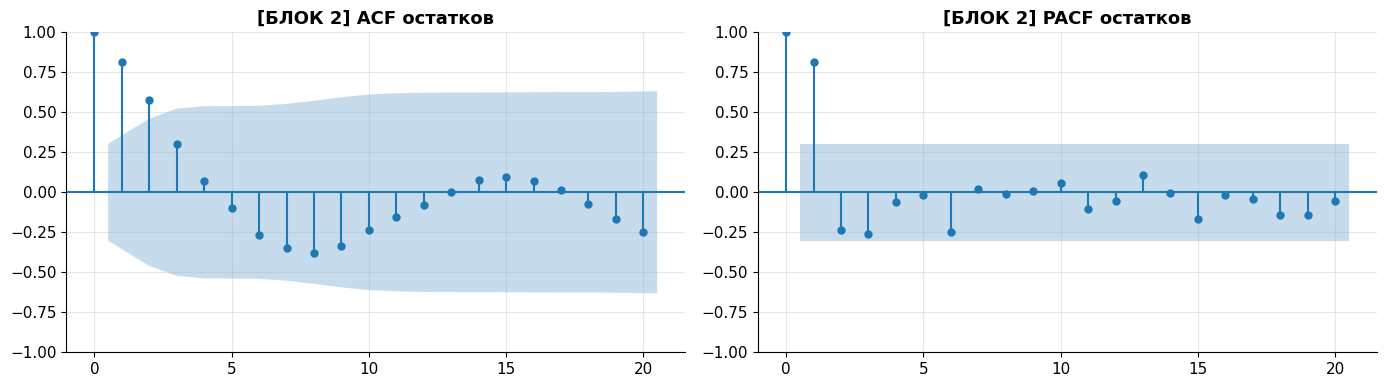

In [30]:

# БЛОК 2 | Диагностика: DW, Льюнга-Бокса, Mincer-Zarnowitz
h   = 12
y_k = cbr_m.shift(-h).dropna()
idx = (y_k.index.intersection(exp_12.dropna().index)
               .intersection(controls.dropna().index))
X_k = sm.add_constant(pd.concat([exp_12.loc[idx].rename('E_rate'),
                                  controls.loc[idx]], axis=1), has_constant='add')
diag_df = pd.concat([y_k.loc[idx].rename('y'), pd.DataFrame(X_k, index=idx)], axis=1).dropna()
m_k = sm.OLS(diag_df['y'], diag_df.drop(columns='y')).fit()

lb  = acorr_ljungbox(m_k.resid, lags=[6,12,24], return_df=True)
dw  = sm.stats.durbin_watson(m_k.resid)
mz_X = sm.add_constant(pd.Series(m_k.fittedvalues, index=diag_df.index, name='fitted'), has_constant='add')
mz  = sm.OLS(diag_df['y'], mz_X).fit()
mz_f = mz.f_test('const = 0, fitted = 1')
mz_f_fvalue = float(np.asarray(mz_f.fvalue).squeeze())
mz_f_pvalue = float(np.asarray(mz_f.pvalue).squeeze())

print('=== [БЛОК 2] Диагностика регрессии (ключевая ставка, h=12) ===')
print(f'Дарбин–Уотсон:  {dw:.3f}  (норма ≈ 2.0)')
print(f'Тест Льюнга–Бокса:\n{lb.to_string()}')
print(f'Mincer–Zarnowitz (a=0, b=1): F={mz_f_fvalue:.3f}, p={mz_f_pvalue:.4f}')
print(f'  → Гипотеза эффективности прогноза: '
      f'{"НЕ отвергается" if mz_f_pvalue>0.05 else "ОТВЕРГАЕТСЯ"}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
max_lags = max(1, min(20, len(m_k.resid)//2 - 1))
plot_acf(m_k.resid, lags=max_lags, ax=axes[0])
axes[0].set_title('[БЛОК 2] ACF остатков', fontweight='bold')
plot_pacf(m_k.resid, lags=max_lags, ax=axes[1], method='ywm')
axes[1].set_title('[БЛОК 2] PACF остатков', fontweight='bold')
plt.tight_layout(); plt.show()


---
# БЛОК 3. Факторный анализ премии за срочность
> **[50 баллов + до 50 дополнительных]**
>
> Два набора факторов: макроэкономические (теоретически обоснованные) и рыночные.  
> Историческая декомпозиция TP. Экономическая интерпретация.

In [31]:
# БЛОК 3 | НАБОР А: макроэкономические факторы
tp5_m = tp_5y.resample('ME').mean()

set_A = pd.DataFrame({
    'real_rate':      cbr_m - cpi['CPI_yoy'].resample('ME').last().reindex(cbr_m.index),
    'infl_vol':       cpi['CPI_mom_pct'].resample('ME').last().rolling(6).std(),
    'slope':          ofz_m['OFZ_5Y'] - cbr_m.reindex(ofz_m.index),
    'us_tp':          tp_us_m['US_TP_10Y'],
    'country_spread': ofz_m['OFZ_5Y'] - ust10y_m['UST_10Y'].reindex(ofz_m.index),
    'output_gap':     output_gap_m,
    'reer_yoy':       reer_yoy.resample('ME').last(),
}).dropna(how='all')

idx_a  = tp5_m.dropna().index.intersection(set_A.dropna().index)
cols_a = [c for c in set_A.columns if set_A.loc[idx_a, c].notna().sum() > 30]
X_a    = sm.add_constant(set_A.loc[idx_a, cols_a])
reg_A  = sm.OLS(tp5_m.loc[idx_a], X_a).fit(cov_type='HAC', cov_kwds={'maxlags':12})

print('[БЛОК 3 | Набор А] Макрофакторы — результаты')
print(reg_A.summary())

[БЛОК 3 | Набор А] Макрофакторы — результаты
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     71.02
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           1.52e-20
Time:                        12:10:35   Log-Likelihood:                -16.636
No. Observations:                  48   AIC:                             49.27
Df Residuals:                      40   BIC:                             64.24
Df Model:                           7                                         
Covariance Type:                  HAC                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------

In [32]:
# БЛОК 3 | НАБОР Б: рыночные / PCA-факторы
set_B = pd.DataFrame({
    'pca_level': factors_pca['Level'].reindex(set_A.index),
    'pca_slope': factors_pca['Slope'].reindex(set_A.index),
    'pca_curv':  factors_pca['Curvature'].reindex(set_A.index),
    'cp_factor': cp_factor.reindex(set_A.index),
    'ns_slope':  ns_df['NS_b2'].reindex(set_A.index),
}).dropna(how='all')

idx_b  = tp5_m.dropna().index.intersection(set_B.dropna().index)
cols_b = [c for c in set_B.columns if set_B.loc[idx_b, c].notna().sum() > 30]
X_b    = sm.add_constant(set_B.loc[idx_b, cols_b])
reg_B  = sm.OLS(tp5_m.loc[idx_b], X_b).fit(cov_type='HAC', cov_kwds={'maxlags':12})

print('[БЛОК 3 | Набор Б] Рыночные факторы — результаты')
print(reg_B.summary())
print(f'\n[БЛОК 3] Сравнение: Набор А R²={reg_A.rsquared:.3f} | Набор Б R²={reg_B.rsquared:.3f}')

[БЛОК 3 | Набор Б] Рыночные факторы — результаты
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     15.48
Date:                Mon, 13 Apr 2026   Prob (F-statistic):           5.47e-09
Time:                        12:10:35   Log-Likelihood:                -45.322
No. Observations:                  53   AIC:                             102.6
Df Residuals:                      47   BIC:                             114.5
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
con

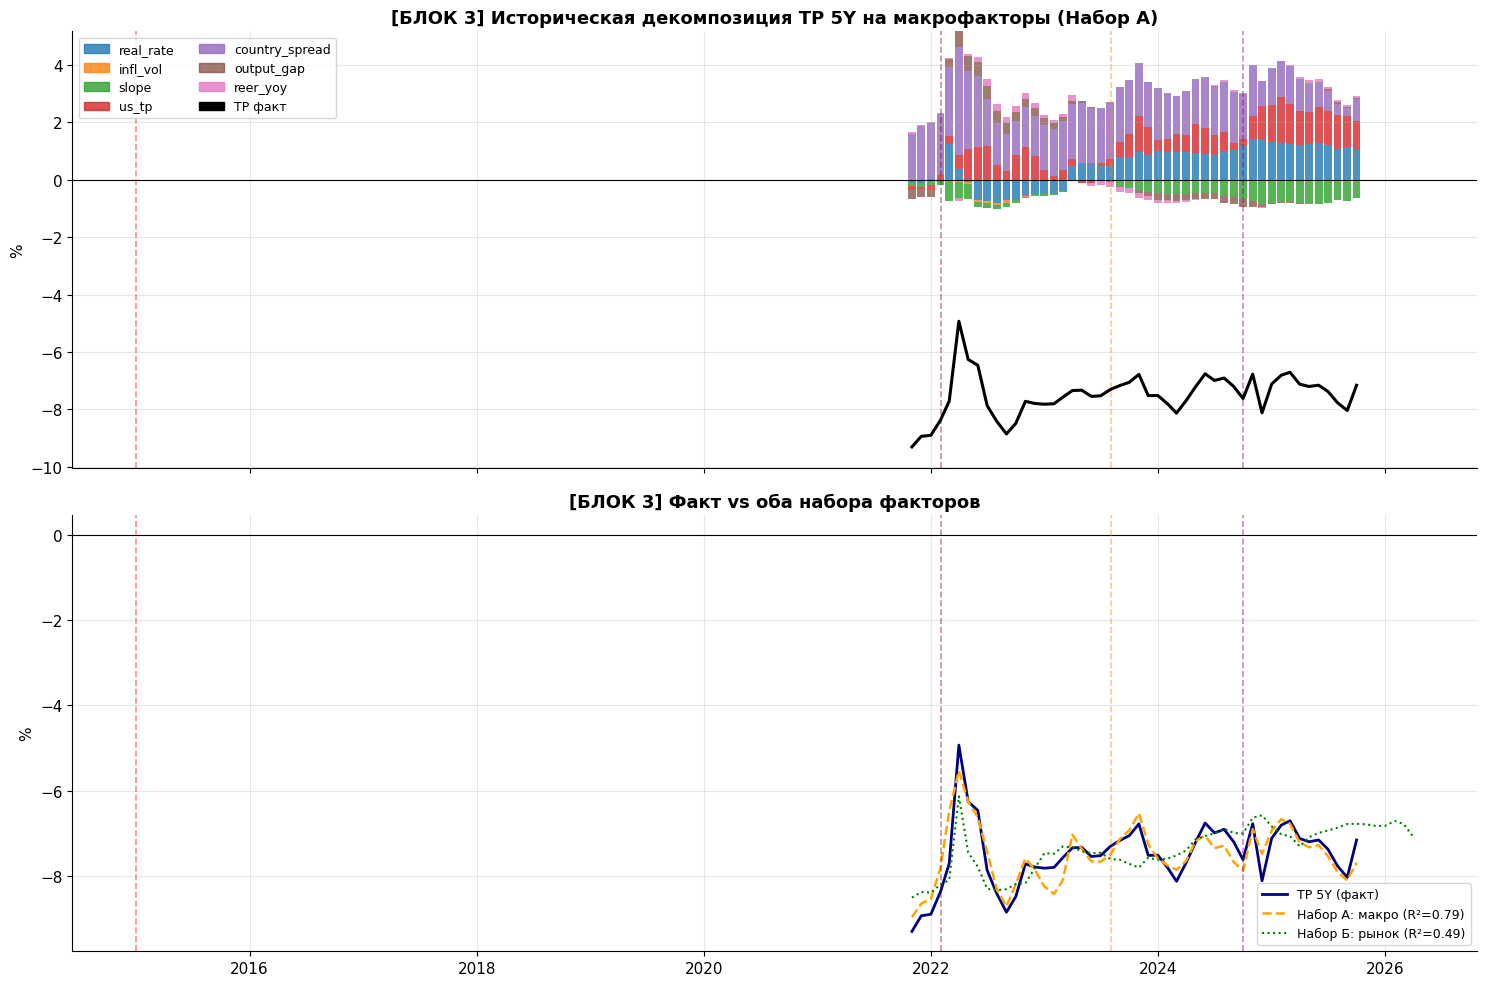

In [33]:
# БЛОК 3 | Историческая декомпозиция TP на факторы
contrib = pd.DataFrame(index=idx_a)
for col in cols_a:
    b = reg_A.params.get(col, 0)
    contrib[col] = b * set_A.loc[idx_a, col]

fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

pos = contrib.clip(lower=0)
neg = contrib.clip(upper=0)
bp, bn = np.zeros(len(contrib)), np.zeros(len(contrib))
patches = []
for i, col in enumerate(cols_a):
    c = C[i % len(C)]
    axes[0].bar(contrib.index, pos[col], bottom=bp, color=c, alpha=0.8, width=25)
    axes[0].bar(contrib.index, neg[col], bottom=bn, color=c, alpha=0.8, width=25)
    bp += pos[col].values
    bn += neg[col].values
    patches.append(mpatches.Patch(color=c, alpha=0.8, label=col))
axes[0].plot(tp5_m.loc[idx_a].index, tp5_m.loc[idx_a].values,
             color='black', lw=2.2, label='TP 5Y (факт)', zorder=5)
axes[0].axhline(0, color='black', lw=0.8)
add_events(axes[0])
axes[0].legend(handles=patches+[mpatches.Patch(color='black',label='TP факт')],
               fontsize=9, loc='upper left', ncol=2)
axes[0].set_title('[БЛОК 3] Историческая декомпозиция TP 5Y на макрофакторы (Набор А)',
                  fontweight='bold')
axes[0].set_ylabel('%')

axes[1].plot(tp5_m.loc[idx_a].index, tp5_m.loc[idx_a].values,
             lw=2, color='navy', label='TP 5Y (факт)')
axes[1].plot(reg_A.fittedvalues.index, reg_A.fittedvalues.values,
             lw=1.8, ls='--', color='orange',
             label=f'Набор А: макро (R²={reg_A.rsquared:.2f})')
axes[1].plot(reg_B.fittedvalues.index, reg_B.fittedvalues.values,
             lw=1.5, ls=':', color='green',
             label=f'Набор Б: рынок (R²={reg_B.rsquared:.2f})')
axes[1].axhline(0, color='black', lw=0.8)
add_events(axes[1])
axes[1].set_title('[БЛОК 3] Факт vs оба набора факторов', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout(); plt.show()

In [34]:
# БЛОК 3 | Экономическая интерпретация
interp = {
    'real_rate':      '↑ реальная ставка → ↓ TP (рынок ждёт нормализации)',
    'infl_vol':       '↑ инфляц. неопред. → ↑ TP (компенсация за риск)',
    'slope':          '↓ наклон (инверсия) → ↓ TP (рынок ждёт снижения)',
    'us_tp':          'глобальный аппетит к риску синхронизирован с РФ',
    'country_spread': '↑ геополит. риск → ↑ TP (сверхдоходность за страновой риск)',
    'output_gap':     '↑ перегрев ВВП → ↑ инфл. ожидания → ↑ TP',
    'reer_yoy':       '↑ укрепление рубля → ↓ инфл. давление → ↓ TP',
}

contrib_mean = contrib.abs().mean()
contrib_share = (contrib_mean / contrib_mean.sum() * 100).sort_values(ascending=False)

print('=== [БЛОК 3] Экономическая интерпретация коэффициентов (Набор А) ===')
for col in cols_a:
    b  = reg_A.params.get(col, np.nan)
    p  = reg_A.pvalues.get(col, np.nan)
    if np.isnan(b): continue
    sg = '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else ''
    print(f'  {col:<20} β={b:+.4f} {sg}  | {interp.get(col,"")}')

print(f'\n=== [БЛОК 3] Относительный вклад факторов ===')
for col, share in contrib_share.items():
    print(f'  {col:<20} {share:.1f}%')

=== [БЛОК 3] Экономическая интерпретация коэффициентов (Набор А) ===
  real_rate            β=+0.1139 ***  | ↑ реальная ставка → ↓ TP (рынок ждёт нормализации)
  infl_vol             β=-0.0275   | ↑ инфляц. неопред. → ↑ TP (компенсация за риск)
  slope                β=+0.0558   | ↓ наклон (инверсия) → ↓ TP (рынок ждёт снижения)
  us_tp                β=+2.2183 ***  | глобальный аппетит к риску синхронизирован с РФ
  country_spread       β=+0.5086 ***  | ↑ геополит. риск → ↑ TP (сверхдоходность за страновой риск)
  output_gap           β=-0.1448 **  | ↑ перегрев ВВП → ↑ инфл. ожидания → ↑ TP
  reer_yoy             β=+0.0049   | ↑ укрепление рубля → ↓ инфл. давление → ↓ TP

=== [БЛОК 3] Относительный вклад факторов ===
  country_spread       42.2%
  real_rate            21.1%
  us_tp                18.4%
  slope                10.5%
  output_gap           4.8%
  reer_yoy             2.6%
  infl_vol             0.5%


---
# БЛОК 4. Рекомендации по денежно-кредитной политике
> **[оцениваются бизнес-жюри]**
>
> Текущая динамика ожиданий и Term Premium.  
> Количественные сценарии. Обоснованные рекомендации.

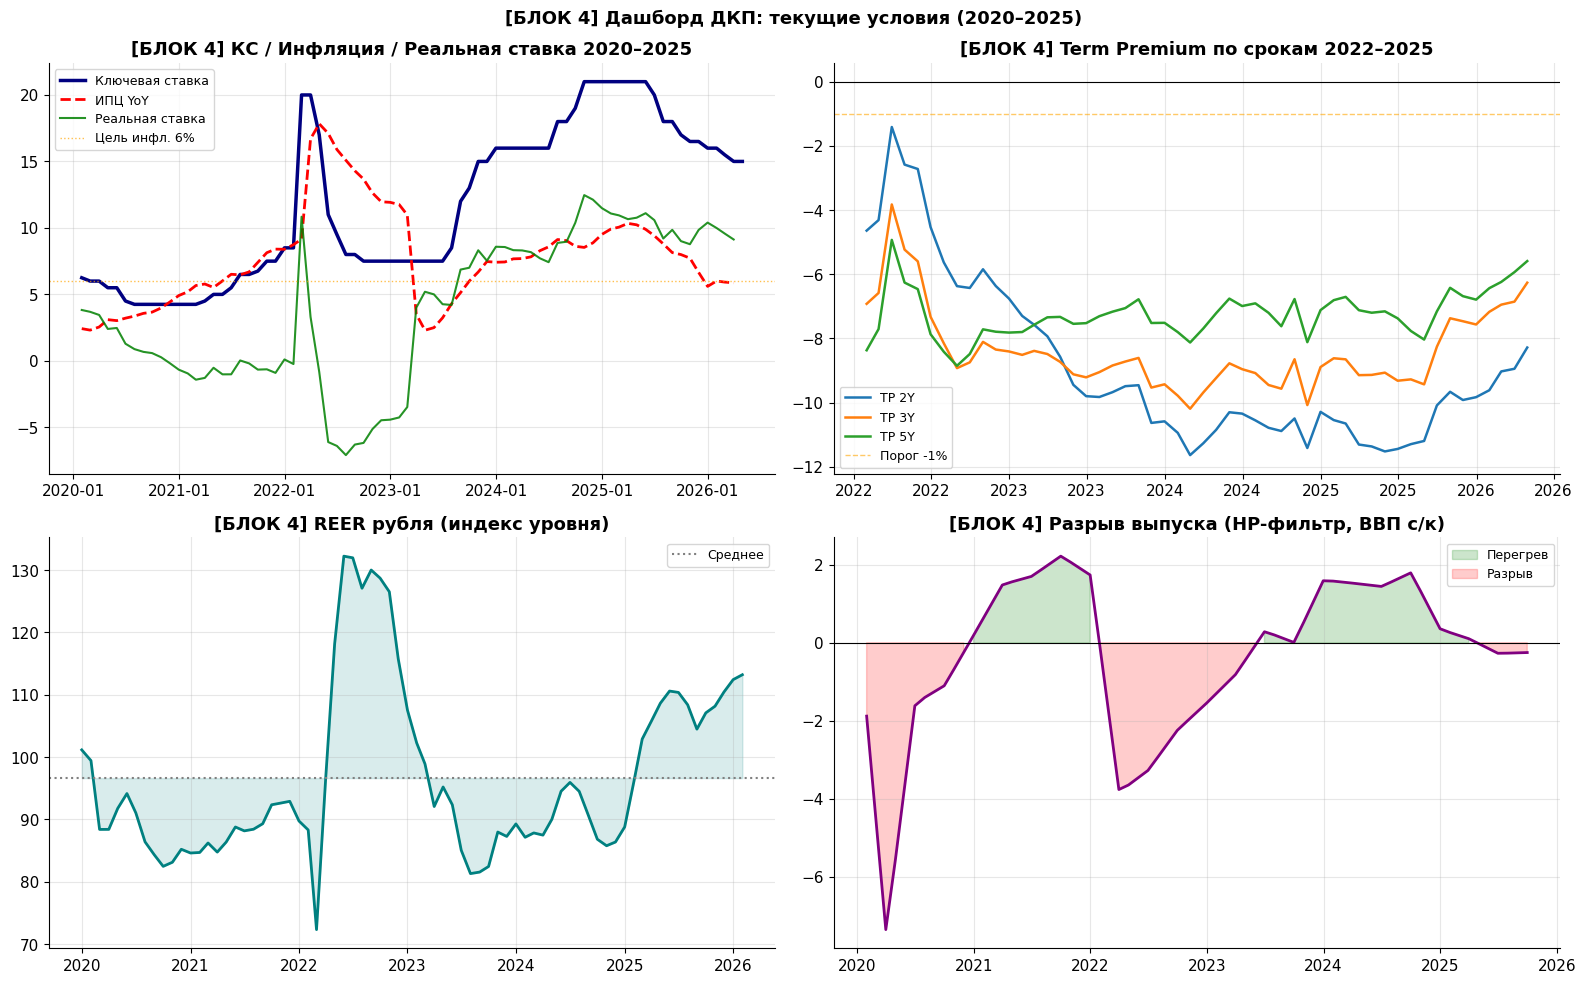

In [35]:
# ── БЛОК 4 | Дашборд текущей ситуации ────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. КС vs инфляция vs реальная ставка
ax = axes[0,0]
kr_r  = cbr_m.loc['2020':]
cpi_r = cpi['CPI_yoy'].resample('ME').last().loc['2020':].dropna()
real_r = (cbr_m - cpi['CPI_yoy'].resample('ME').last().reindex(cbr_m.index)).loc['2020':]
ax.plot(kr_r.index, kr_r.values, lw=2.5, color='navy', label='Ключевая ставка')
ax.plot(cpi_r.index, cpi_r.values, lw=2, ls='--', color='red', label='ИПЦ YoY')
ax.plot(real_r.index, real_r.values, lw=1.5, color='green', alpha=0.85,
        label='Реальная ставка')
ax.axhline(6, color='orange', lw=1, ls=':', alpha=0.7, label='Цель инфл. 6%')
ax.set_title('[БЛОК 4] КС / Инфляция / Реальная ставка 2020–2025', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# 2. Term Premium (все сроки) 2022–
ax = axes[0,1]
for col, lbl, c in zip(tp_df.columns, ['TP 2Y','TP 3Y','TP 5Y'], C):
    s = tp_df[col].loc['2022':]
    ax.plot(s.index, s.values, lw=1.8, label=lbl, color=c)
ax.axhline(0, color='black', lw=0.8)
ax.axhline(-1, color='orange', lw=1, ls='--', alpha=0.6, label='Порог -1%')
ax.set_title('[БЛОК 4] Term Premium по срокам 2022–2025', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 3. REER уровень 2020–
ax = axes[1,0]
reer_plot = reer_level.loc['2020':].dropna()
ax.plot(reer_plot.index, reer_plot.values, lw=2, color='teal')
ax.fill_between(reer_plot.index, reer_plot.values,
                reer_plot.mean(), alpha=0.15, color='teal')
ax.axhline(reer_plot.mean(), color='gray', ls=':', label='Среднее')
ax.set_title('[БЛОК 4] REER рубля (индекс уровня)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 4. ВВП разрыв выпуска
ax = axes[1,1]
og = output_gap_m.loc['2020':].dropna()
ax.plot(og.index, og.values, lw=2, color='purple')
ax.fill_between(og.index, og.values, 0,
                where=og.values>0, alpha=0.2, color='green', label='Перегрев')
ax.fill_between(og.index, og.values, 0,
                where=og.values<0, alpha=0.2, color='red', label='Разрыв')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('[БЛОК 4] Разрыв выпуска (HP-фильтр, ВВП с/к)', fontweight='bold')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('[БЛОК 4] Дашборд ДКП: текущие условия (2020–2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [39]:
# ── БЛОК 4 | Количественные сценарии ─────────────────────────────────────
cur_kr    = cbr_m.iloc[-1]
cur_cpi   = cpi['CPI_yoy'].resample('ME').last().dropna().iloc[-1]
cur_real  = cur_kr - cur_cpi
cur_tp5   = tp_5y.iloc[-1]
cur_slope = ofz_m['OFZ_5Y'].dropna().iloc[-1] - cur_kr
cur_reer  = reer_level.dropna().iloc[-1]
cur_gap   = output_gap_m.dropna().iloc[-1]

print('=== [БЛОК 4] ТЕКУЩИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ИНДИКАТОРОВ ===')
print(f'  Ключевая ставка:       {cur_kr:.1f}%')
print(f'  ИПЦ YoY:              {cur_cpi:.1f}%')
print(f'  Реальная ставка:       {cur_real:.1f}%')
print(f'  Term Premium 5Y:       {cur_tp5:.2f}%')
print(f'  Наклон (ОФЗ5Y − КС):  {cur_slope:.1f} п.п.')
print(f'  REER (уровень):        {cur_reer:.1f}')
print(f'  Разрыв выпуска:        {cur_gap:.2f}%')

print(f"""
=== [БЛОК 4] СЦЕНАРНЫЙ АНАЛИЗ ===

Сценарий 1 — УДЕРЖАНИЕ (базовый):
  Условие: ИПЦ > 7% ИЛИ TP < −1%
  Сейчас:  ИПЦ = {cur_cpi:.1f}%, TP = {cur_tp5:.2f}%
  Статус:  {'АКТИВЕН' if cur_cpi > 7 or cur_tp5 < -1 else '✗ не активен'}

Сценарий 2 — ПЕРВОЕ СНИЖЕНИЕ (−100 б.п.):
  Условие: ИПЦ < 7% И TP > −1% И наклон > −3 п.п.
  Сейчас:  ИПЦ = {cur_cpi:.1f}%, TP = {cur_tp5:.2f}%, наклон = {cur_slope:.1f} п.п.
  Статус:  {'УСЛОВИЕ ВЫПОЛНЕНО' if cur_cpi < 7 and cur_tp5 > -1 and cur_slope > -3 else '✗ не выполнено'}

Сценарий 3 — ЦИКЛ СМЯГЧЕНИЯ:
  Условие: ИПЦ ≤ 6% устойчиво 3 мес. И TP > 0%
  Цель: реальная ставка = 3–4%, КС ≈ 10–12% при инфляции 6–7%
""")

=== [БЛОК 4] ТЕКУЩИЕ ЗНАЧЕНИЯ КЛЮЧЕВЫХ ИНДИКАТОРОВ ===
  Ключевая ставка:       15.0%
  ИПЦ YoY:              5.9%
  Реальная ставка:       9.1%
  Term Premium 5Y:       -5.59%
  Наклон (ОФЗ5Y − КС):  -8.4 п.п.
  REER (уровень):        113.2
  Разрыв выпуска:        -0.25%

=== [БЛОК 4] СЦЕНАРНЫЙ АНАЛИЗ ===

Сценарий 1 — УДЕРЖАНИЕ (базовый):
  Условие: ИПЦ > 7% ИЛИ TP < −1%
  Сейчас:  ИПЦ = 5.9%, TP = -5.59%
  Статус:  АКТИВЕН

Сценарий 2 — ПЕРВОЕ СНИЖЕНИЕ (−100 б.п.):
  Условие: ИПЦ < 7% И TP > −1% И наклон > −3 п.п.
  Сейчас:  ИПЦ = 5.9%, TP = -5.59%, наклон = -8.4 п.п.
  Статус:  ✗ не выполнено

Сценарий 3 — ЦИКЛ СМЯГЧЕНИЯ:
  Условие: ИПЦ ≤ 6% устойчиво 3 мес. И TP > 0%
  Цель: реальная ставка = 3–4%, КС ≈ 10–12% при инфляции 6–7%



**Рекомендации:**

1. Сигнал term premium (TP)

TP на горизонте 5 лет остаётся глубоко отрицательной, что указывает на ожидания снижения ключевой ставки в среднесрочной перспективе. Кривая доходности остаётся инвертированной.

2. Прогнозная сила ожиданий

Оценённые ожидания демонстрируют наибольшую информативность на горизонте 12 месяцев:

для ключевой ставки и инфляции наблюдается значимое улучшение качества прогноза (снижение RMSE),
для REER также есть положительный эффект, хотя он менее устойчив статистически.

На горизонтах 24–36 месяцев информативность ожиданий снижается, что связано как с экономической неопределённостью, так и с сокращением доступной выборки.

3. Факторы term premium

Основными драйверами TP являются:

страновой спред (country spread),
реальная процентная ставка,
глобальная term premium (США).

Это указывает на то, что TP формируется под влиянием как внутренних условий денежно-кредитной политики, так и внешних факторов риска.

4. Рекомендации для Банка России

а) Политика ключевой ставки
Не рекомендуется спешить со снижением ключевой ставки, пока TP остаётся существенно отрицательной и кривая доходности глубоко инвертирована.

б) Коммуникационная политика
В коммуникации важно чётко разделять:

ожидания по траектории ключевой ставки,
и премию за срочность (term premium).

Снижение долгосрочных ставок не обязательно означает ожидание быстрого смягчения политики.

в) Условия для начала снижения ставки
Снижение ключевой ставки целесообразно при выполнении совокупности условий:

устойчивое снижение инфляции (CPI YoY) до уровня около 6% или ниже,
уменьшение отрицательности TP,
сокращение инверсии кривой доходности.

г) Мониторинг ключевых индикаторов
Для оценки момента нормализации политики рекомендуется отслеживать:

страновой спред,
реальную процентную ставку,
динамику REER,
глобальную term premium (США).

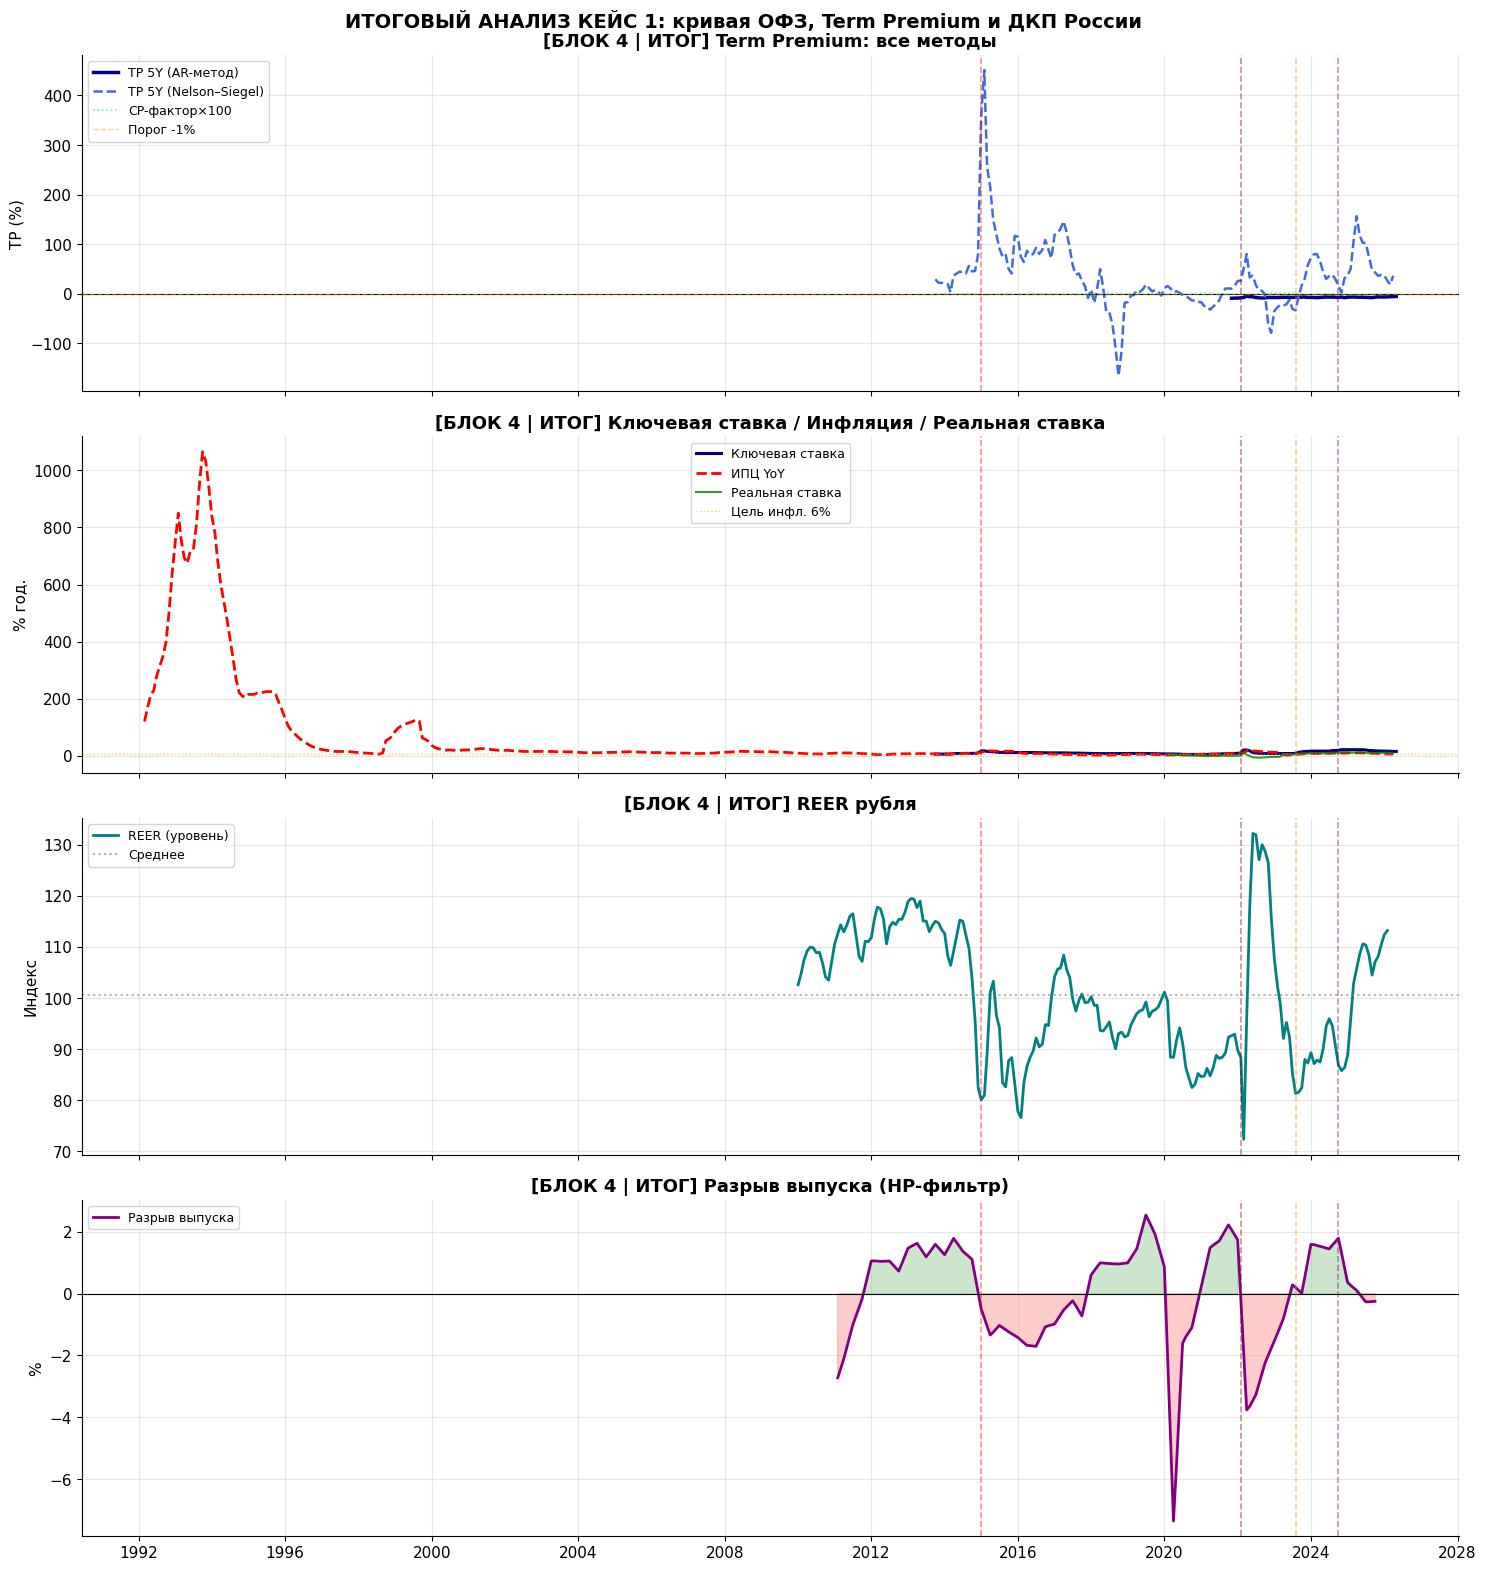

In [38]:
# ── БЛОК 4 | Итоговый сводный график ─────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(15, 16), sharex=True)

# 1. Все методы TP
axes[0].plot(tp5_m.index, tp5_m, lw=2.5, color='darkblue', label='TP 5Y (AR-метод)')
axes[0].plot(ns_tp.index, ns_tp, lw=1.8, ls='--', color='royalblue',
             label='TP 5Y (Nelson–Siegel)')
axes[0].plot(cp_factor.index, cp_factor*100, lw=1.2, ls=':', color='cyan',
             alpha=0.7, label='CP-фактор×100')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(-1, color='orange', lw=1, ls='--', alpha=0.5, label='Порог -1%')
add_events(axes[0])
axes[0].set_title('[БЛОК 4 | ИТОГ] Term Premium: все методы', fontweight='bold')
axes[0].set_ylabel('TP (%)')
axes[0].legend(fontsize=9)

# 2. КС + инфляция
axes[1].plot(cbr_m.index, cbr_m.values, lw=2.2, color='navy', label='Ключевая ставка')
axes[1].plot(cpi['CPI_yoy'].resample('ME').last().dropna().index,
             cpi['CPI_yoy'].resample('ME').last().dropna().values,
             lw=2, ls='--', color='red', label='ИПЦ YoY')
axes[1].plot(real_r.index, real_r.values, lw=1.5, color='green',
             alpha=0.8, label='Реальная ставка')
axes[1].axhline(6, color='orange', lw=1, ls=':', alpha=0.6, label='Цель инфл. 6%')
add_events(axes[1])
axes[1].set_title('[БЛОК 4 | ИТОГ] Ключевая ставка / Инфляция / Реальная ставка',
                  fontweight='bold')
axes[1].set_ylabel('% год.')
axes[1].legend(fontsize=9)

# 3. REER
axes[2].plot(reer_level.dropna().index, reer_level.dropna().values,
             lw=2, color='teal', label='REER (уровень)')
axes[2].axhline(reer_level.mean(), color='gray', ls=':', alpha=0.6, label='Среднее')
add_events(axes[2])
axes[2].set_title('[БЛОК 4 | ИТОГ] REER рубля', fontweight='bold')
axes[2].set_ylabel('Индекс')
axes[2].legend(fontsize=9)

# 4. Разрыв выпуска
axes[3].plot(output_gap_m.dropna().index, output_gap_m.dropna().values,
             lw=2, color='purple', label='Разрыв выпуска')
axes[3].fill_between(output_gap_m.dropna().index, output_gap_m.dropna().values, 0,
                     where=output_gap_m.dropna().values>0, alpha=0.2, color='green')
axes[3].fill_between(output_gap_m.dropna().index, output_gap_m.dropna().values, 0,
                     where=output_gap_m.dropna().values<0, alpha=0.2, color='red')
axes[3].axhline(0, color='black', lw=0.8)
add_events(axes[3])
axes[3].set_title('[БЛОК 4 | ИТОГ] Разрыв выпуска (HP-фильтр)', fontweight='bold')
axes[3].set_ylabel('%')
axes[3].legend(fontsize=9)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('ИТОГОВЫЙ АНАЛИЗ КЕЙС 1: кривая ОФЗ, Term Premium и ДКП России',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()